# Question 1 — Group project: us and the AI
### Course: 21046 Data Science and Machine Learning for Finance (Bocconi University, 2025/2026)
## Premises on the use of AI

Most of the code below was directly generated by AI. We told it what we needed and then inspected the code that was given to us. In case of doubt, we asked another AI to explain what the lines of code we were unsure about were doing (without telling the new AI what we expected the code to do), in order to check whether the code was actually doing what we needed.

Any comment of the finding has been written first by discussing the results among ourselves, then providing AI with our findings and checking whether it converged to the same explanation we had in mind, without explicitly stating our interpretation. In case of disagreement, we checked online and consulted other AIs to see who was right.



In [8]:
# ============================================================
# INSTALL (run once, then restart kernel)
# ============================================================
!pip install tensorflow

# ============================================================
# STANDARD LIBRARIES
# ============================================================
import os
from datetime import datetime, timedelta

# ============================================================
# DATA / NUMERICAL
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import plotly.express as px

# ============================================================
# DATA SOURCES
# ============================================================
import yfinance as yf

# ============================================================
# SCIENTIFIC / STATS
# ============================================================
from scipy import stats
from scipy.optimize import differential_evolution, minimize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from statsmodels.stats.diagnostic import lilliefors

# ============================================================
# MACHINE LEARNING
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import davies_bouldin_score

# ============================================================
# OPTIMIZATION
# ============================================================
import cvxpy as cp

# ============================================================
# TENSORFLOW / AUTOENCODER
# ============================================================
import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1) download (any public) data on stock prices (at least 100 stocks)
# ============================================================

# File names
constituents_file = "sp500_constituents.csv"
prices_file = "sp500_adj_close.csv"
market_caps_file = "sp500_market_caps.csv"

# GitHub raw base URL
github_base_url = "https://raw.githubusercontent.com/stfgrz/21046-mlf-ps/main/data/"

constituents_github_url = github_base_url + constituents_file
prices_github_url = github_base_url + prices_file
market_caps_github_url = github_base_url + market_caps_file

# Load S&P 500 constituents from GitHub; if unavailable, download from public source
try:
    sp500 = pd.read_csv(constituents_github_url)
    print("Loaded S&P 500 constituents from GitHub")

except Exception:
    url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
    sp500 = pd.read_csv(url)
    sp500.to_csv(constituents_file, index=False)
    print("Downloaded S&P 500 constituents from public source")

# Define tickers
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist()

# Load adjusted close prices from GitHub; if unavailable, download from Yahoo Finance
try:
    prices_clean = pd.read_csv(
        prices_github_url,
        index_col=0,
        parse_dates=True
    )
    print("Loaded adjusted prices from GitHub")

except Exception:
    start_date = "2015-01-01"
    end_date = "2026-01-01"

    prices = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )["Adj Close"]

    prices_clean = prices.dropna(axis=1)
    prices_clean.to_csv(prices_file)

    print("Downloaded adjusted prices from Yahoo Finance")
    print(f"Original number of stocks: {prices.shape[1]}")
    print(f"Final number of stocks with full history: {prices_clean.shape[1]}")

# Load market caps from GitHub; if unavailable, download from Yahoo Finance
try:
    market_caps = pd.read_csv(
        market_caps_github_url,
        index_col=0
    ).squeeze("columns")
    print("Loaded market caps from GitHub")

except Exception:
    print("Downloading market caps from Yahoo Finance...")

    market_caps_dict = {}

    for ticker in prices_clean.columns:
        try:
            info = yf.Ticker(ticker).info
            market_caps_dict[ticker] = info.get("marketCap", None)
        except Exception:
            market_caps_dict[ticker] = None

    market_caps = pd.Series(market_caps_dict).dropna()
    market_caps.name = "market_cap"
    market_caps.to_csv(market_caps_file)

    print("Downloaded market caps from Yahoo Finance")
    print(f"Market cap available for {len(market_caps)} stocks")

# Keep only stocks that have both prices and market cap
common_tickers = prices_clean.columns.intersection(market_caps.index)

prices_clean = prices_clean[common_tickers]
market_caps = market_caps.loc[common_tickers]

assert prices_clean.shape[1] >= 100, "The dataset contains fewer than 100 stocks."

print("\nFinal aligned dataset:")
print(f"Number of stocks with prices: {prices_clean.shape[1]}")
print(f"Number of stocks with market cap: {len(market_caps)}")
print(f"Date range: {prices_clean.index.min().date()} to {prices_clean.index.max().date()}")

Loaded S&P 500 constituents from GitHub
Loaded adjusted prices from GitHub
Loaded market caps from GitHub

Final aligned dataset:
Number of stocks with prices: 461
Number of stocks with market cap: 461
Date range: 2015-01-02 to 2025-12-31


We asked AI for an easy way to download S&P 500 stock prices. The AI initially suggested downloading stock price data with yfinance. However, yfinance requires a list of ticker symbols as input, so we needed an external source for the S&P 500 constituent list. The AI suggested scraping the ticker list from Wikipedia. This turned out to be problematic.

Then we asked for a better alternative. The AI suggested using a public CSV file from the Open Knowledge Foundation on GitHub (https://github.com/datasets/s-and-p-500-companies). We checked the README file available on the GitHub repository and the website of the foundation (which we did not know before). It seems to be a reliable source.

After downloading the data, stocks with missing values across the full 10-year period were dropped, resulting in a final sample of 461 out of 500 companies. While the number of excluded companies may seem small, this introduces a non-trivial form of survivorship bias. The excluded companies are not missing at random; they are systematically the worst-performing or most troubled ones, making the remaining sample look artificially healthier than the true market.

We asked the AI whether a survivorship-bias-free analysis was possible. The historically accurate day-by-day index composition would be too complex, so we chose to focus on
 the companies currently listed in the index.

We also downloaded the current capitalization of the stocks. We will use this information in descriptive statistics to obtain weighted averages of returns. We are aware that these weights are misleading, since for the entire period we are using today’s capitalization instead of the capitalization specific to each period.

N.B. We are aware that in file A03c weekly stock prices were used to avoid microstructure noise, but we preferred to use daily data for two reasons:
1. It gives us many more observations to estimate our optimal portfolio more reliably;
2. since part of this analysis overlaps with what was done in class, working at a different frequency gave us a chance to spot whether and how the results change.

In [ ]:
# ============================================================
# 2) compute linear returns
# ============================================================

# Get and print daily returns per company
returns = prices_clean.pct_change().dropna()

print(returns.head(3))

Ticker             A      AAPL      ABBV       ABT      ACGL       ACN  \
Date                                                                     
2015-01-05 -0.018738 -0.028172 -0.018819  0.000222 -0.005984 -0.016884   
2015-01-06 -0.015579  0.000094 -0.004950 -0.011356  0.002236 -0.007213   
2015-01-07  0.013273  0.014022  0.040417  0.008108  0.005835  0.020990   

Ticker          ADBE       ADI       ADM       ADP  ...       WTW        WY  \
Date                                                ...                       
2015-01-05 -0.004976 -0.018185 -0.034602 -0.000721  ... -0.007183  0.000000   
2015-01-06 -0.020145 -0.023473 -0.019713 -0.008290  ... -0.004974 -0.001108   
2015-01-07  0.008223  0.010516  0.015032  0.008723  ...  0.014315  0.003050   

Ticker          WYNN       XEL       XOM       XYL       YUM       ZBH  \
Date                                                                     
2015-01-05 -0.017020 -0.011351 -0.027362 -0.062237 -0.020318  0.037304   
2015-01-06 

Computing descriptive statistics for all stocks...

Descriptive Statistics for all stocks:


,Mean,Median,Std Dev,Variance,MAD,Skewness,Kurtosis,Min,Max,Q25,Q75
Ticker,,,,,,,,,,,
A,0.000615,0.001014,0.017043,0.000290,0.012177,-0.134901,4.346808,-0.110117,0.098394,-0.008000,0.009778
AAPL,0.001039,0.000951,0.018171,0.000330,0.012548,0.140019,6.584567,-0.128647,0.153289,-0.007283,0.010014
ABBV,0.000753,0.001135,0.016745,0.000280,0.011276,-0.724762,11.497138,-0.162524,0.137673,-0.006821,0.008855
ABT,0.000556,0.000702,0.014775,0.000218,0.010324,-0.239041,6.663070,-0.097857,0.109360,-0.006442,0.008397
ACGL,0.000734,0.001042,0.016660,0.000278,0.010899,-0.361744,13.798199,-0.168752,0.153577,-0.006331,0.008457
...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.000650,0.000566,0.016642,0.000277,0.011394,-0.054797,7.424677,-0.120273,0.112620,-0.007273,0.009078
YUM,0.000574,0.000680,0.015034,0.000226,0.009723,0.523086,34.571763,-0.188324,0.232484,-0.006112,0.007403
ZBH,0.000112,0.000101,0.017295,0.000299,0.011411,-0.180178,12.121552,-0.151483,0.155797,-0.007710,0.008346



--- Per Stock Descriptive Statistics ---


,Mean,Median,Std Dev,Variance,MAD,Skewness,Kurtosis,Min,Max,Q25,Q75
Ticker,,,,,,,,,,,
A,0.000615,0.001014,0.017043,0.000290,0.012177,-0.134901,4.346808,-0.110117,0.098394,-0.008000,0.009778
AAPL,0.001039,0.000951,0.018171,0.000330,0.012548,0.140019,6.584567,-0.128647,0.153289,-0.007283,0.010014
ABBV,0.000753,0.001135,0.016745,0.000280,0.011276,-0.724762,11.497138,-0.162524,0.137673,-0.006821,0.008855
ABT,0.000556,0.000702,0.014775,0.000218,0.010324,-0.239041,6.663070,-0.097857,0.109360,-0.006442,0.008397
ACGL,0.000734,0.001042,0.016660,0.000278,0.010899,-0.361744,13.798199,-0.168752,0.153577,-0.006331,0.008457
...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.000650,0.000566,0.016642,0.000277,0.011394,-0.054797,7.424677,-0.120273,0.112620,-0.007273,0.009078
YUM,0.000574,0.000680,0.015034,0.000226,0.009723,0.523086,34.571763,-0.188324,0.232484,-0.006112,0.007403
ZBH,0.000112,0.000101,0.017295,0.000299,0.011411,-0.180178,12.121552,-0.151483,0.155797,-0.007710,0.008346



--- Market Level Summary ---


,Mean,Median,Std Dev,Variance,MAD,Skewness,Kurtosis,Min,Max,Q25,Q75
Equal Weighted Market,0.000641,0.000798,0.019598,0.000410,0.013130,-0.059695,15.556263,-0.181386,0.180850,-0.008484,0.010004
Cap Weighted Market,0.001029,0.001052,0.020306,0.000445,0.013837,0.154152,11.388589,-0.159927,0.181446,-0.008581,0.010878


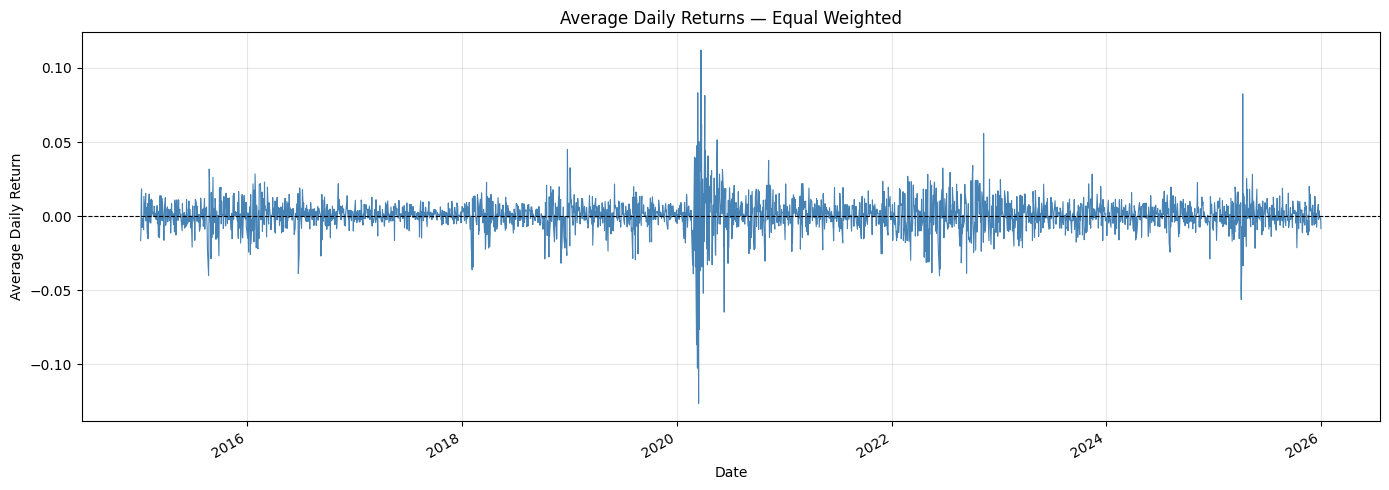

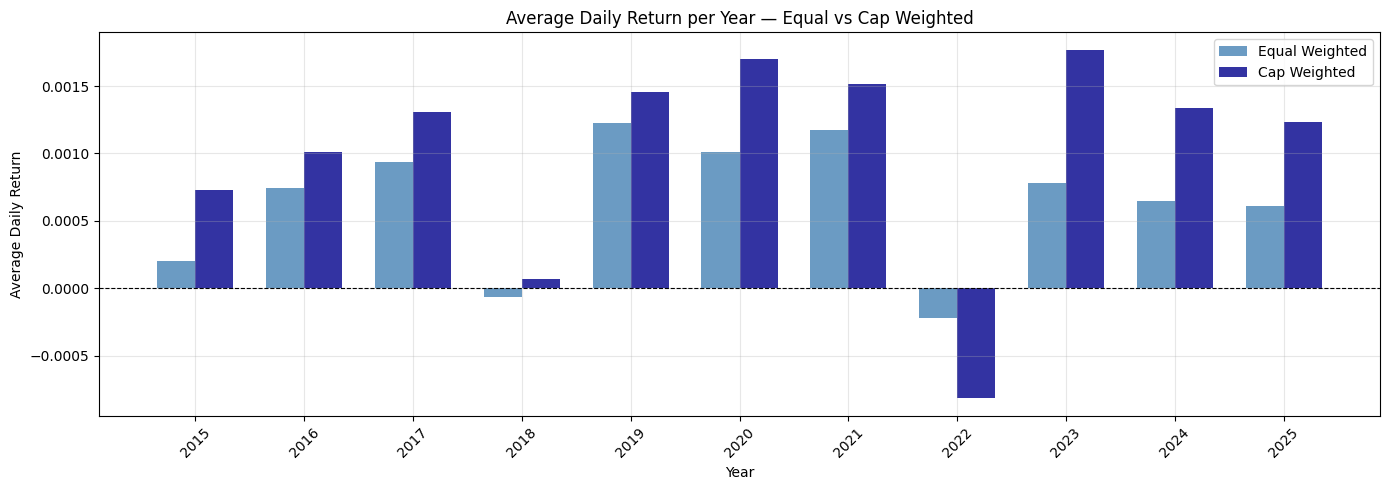

Stocks with Mean > Median: 129
Stocks with Mean < Median: 332
Average (Mean - Median): -0.00015653763790016313

Average Std/MAD ratio: 1.4921718693750694
Median Std/MAD ratio: 1.4782042471126589

Average skewness: -0.059694790494828176
Median skewness: -0.04243820013756918

Average kurtosis: 15.55626284455662
Median kurtosis: 11.482925595544852


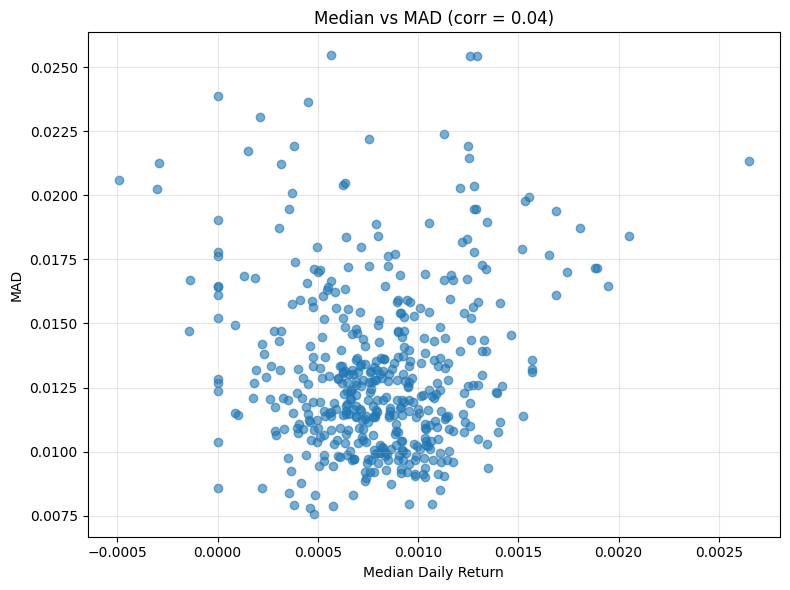

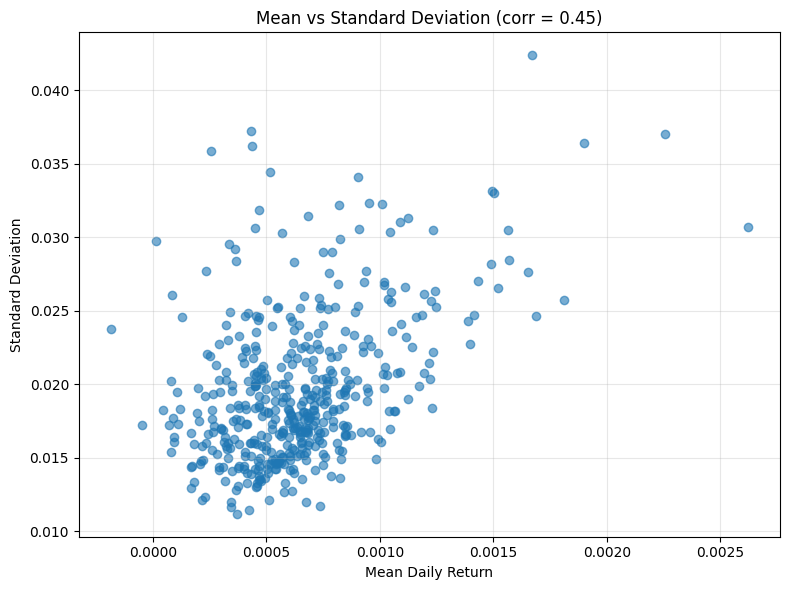

Correlation between Mean and Std Dev: 0.4461622932079298
                           Mean    Median       MAD   Std Dev
Equal Weighted Market  0.000641  0.000798  0.013130  0.019598
Cap Weighted Market    0.001029  0.001052  0.013837  0.020306


In [ ]:

# ============================================================
# 3) compute the main descriptive statistics
# ============================================================

# Obtain and print basic statistics
print("Computing descriptive statistics for all stocks...")

mean        = returns.mean()
median      = returns.median()
std         = returns.std()
variance    = returns.var()
mad         = returns.apply(lambda x: (x - x.median()).abs().mean())
skewness    = returns.skew()
kurtosis    = returns.kurt()
min_ret     = returns.min()
max_ret     = returns.max()
q25         = returns.quantile(0.25)
q75         = returns.quantile(0.75)

desc_stats = pd.DataFrame({
    'Mean'     : mean,
    'Median'   : median,
    'Std Dev'  : std,
    'Variance' : variance,
    'MAD'      : mad,
    'Skewness' : skewness,
    'Kurtosis' : kurtosis,
    'Min'      : min_ret,
    'Max'      : max_ret,
    'Q25'      : q25,
    'Q75'      : q75
})

print("\nDescriptive Statistics for all stocks:")
display(desc_stats)


# Merging data on returns with that on market capitalization
common_tickers     = [t for t in desc_stats.index if t in market_caps.index]
desc_stats_aligned = desc_stats.loc[common_tickers]
weights            = market_caps[common_tickers]
weights            = weights / weights.sum()


# Simple and weighted average return
simple_avg      = desc_stats_aligned.mean()
simple_avg.name = 'Equal Weighted Market'

weighted_avg      = desc_stats_aligned.multiply(weights, axis=0).sum()
weighted_avg.name = 'Cap Weighted Market'

summary = pd.concat([simple_avg, weighted_avg], axis=1).T

print("\n--- Per Stock Descriptive Statistics ---")
display(desc_stats)

print("\n--- Market Level Summary ---")
display(summary)


# PLOT 1: Average daily returns
# ============================================================

avg_returns = returns.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
avg_returns.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Daily Returns — Equal Weighted')
ax.set_ylabel('Average Daily Return')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# PLOT 2: Average return per year — equal vs cap weighted
# ============================================================

avg_returns.index    = pd.to_datetime(avg_returns.index)
yearly_equal         = avg_returns.groupby(avg_returns.index.year).mean()

# Cap weighted average returns
common_ret_tickers   = [t for t in returns.columns if t in market_caps.index]
weights_ret          = market_caps[common_ret_tickers]
weights_ret          = weights_ret / weights_ret.sum()
avg_returns_capw     = returns[common_ret_tickers].dot(weights_ret)
avg_returns_capw.index = pd.to_datetime(avg_returns_capw.index)
yearly_capw          = avg_returns_capw.groupby(avg_returns_capw.index.year).mean()

x     = np.arange(len(yearly_equal))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, yearly_equal.values,
       width, color='steelblue', alpha=0.8, label='Equal Weighted')
ax.bar(x + width/2, yearly_capw.values,
       width, color='darkblue', alpha=0.8, label='Cap Weighted')
ax.set_xticks(x)
ax.set_xticklabels(yearly_equal.index, rotation=45)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Daily Return per Year — Equal vs Cap Weighted')
ax.set_ylabel('Average Daily Return')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Computing results used to comment the main statistics

# 1) Mean vs median
mean_minus_median = desc_stats["Mean"] - desc_stats["Median"]

print("Stocks with Mean > Median:", (mean_minus_median > 0).sum())
print("Stocks with Mean < Median:", (mean_minus_median < 0).sum())
print("Average (Mean - Median):", mean_minus_median.mean())


# 2) MAD vs Std Dev
ratio_std_mad = desc_stats["Std Dev"] / desc_stats["MAD"]

print("\nAverage Std/MAD ratio:", ratio_std_mad.mean())
print("Median Std/MAD ratio:", ratio_std_mad.median())


# 3) Skewness and kurtosis
print("\nAverage skewness:", desc_stats["Skewness"].mean())
print("Median skewness:", desc_stats["Skewness"].median())

print("\nAverage kurtosis:", desc_stats["Kurtosis"].mean())
print("Median kurtosis:", desc_stats["Kurtosis"].median())


# PLOT 3: Median vs MAD
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(desc_stats["Median"], desc_stats["MAD"], alpha=0.6)

# Compute correlation
corr = desc_stats["Median"].corr(desc_stats["MAD"])

ax.set_title(f"Median vs MAD (corr = {corr:.2f})")
ax.set_xlabel("Median Daily Return")
ax.set_ylabel("MAD")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Mean vs Standard Deviation
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(desc_stats["Mean"], desc_stats["Std Dev"], alpha=0.6)

# Compute correlation
corr = desc_stats["Mean"].corr(desc_stats["Std Dev"])

# Labels and title
ax.set_title(f"Mean vs Standard Deviation (corr = {corr:.2f})")
ax.set_xlabel("Mean Daily Return")
ax.set_ylabel("Standard Deviation")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Correlation between Mean and Std Dev:", corr)

# Equal-weighted vs Cap-weighted average yearly return
print(summary[["Mean", "Median", "MAD", "Std Dev"]])


The descriptive statistics provide a first picture of the basic properties of stock returns and help identify some broad stylized facts present in the sample. In selecting which statistics to report, we also explored a wider set of possible measures suggested by AI, and retained only those that seemed the most noticeable to us.

1. The mean value is on average lower than the median value. We did not expect this, but it is plausible that the reason lies in the presence of some large negative return realizations that are not fully compensated by more regular positive returns. The negative value of skewness is consistent with this interpretation. This asymmetry may also have a psychological component: investors typically fear losses more than they value gains, so drawdowns can trigger stronger selling pressure, whereas there is no equally strong “fear of gains” generating a symmetric effect on the upside.

2. SD is higher than MAD, suggesting that the measure we are about to use in the following steps is more robust for analyzing the behavior of returns. Indeed, MAD grows linearly with the distance from the center, while SD is based on squared deviations, so it grows quadratically. As a consequence, extreme values receive much more weight in SD than in MAD.

3. As shown in plot 3, where MAD and median returns are plotted, there is only a weak correlation between MAD and median return. We did not expect that, since we thought there might be a positive relation similar to the one often discussed between SD and mean returns. A possible reason is that the median is less influenced by outliers, whereas investors should care about extreme losses and gains. A large loss remains economically relevant even if it is statistically extreme. So our interpretation is that we do not observe a strong positive relation because these statistics capture different behavioral patterns.

We also added the simple and capitalization-weighted average returns by year and, quite interestingly:

1. For 2018 and 2022 the average return is very small or negative. This seems consistent with the broader economic and geopolitical context. For 2018, a possible explanation is the beginning of the USA–China trade war, which increased uncertainty and weighed on markets. For 2022, the decline can plausibly be linked not only to the invasion of Ukraine, but also to the (partially consequent) high inflation and the sharp increase in interest rates.
2. Returns for the weighted average are always higher in absolute value than the simple average return. This suggests that large firms experience larger aggregate movements than small firms.



SERIES 1: Average market return per day


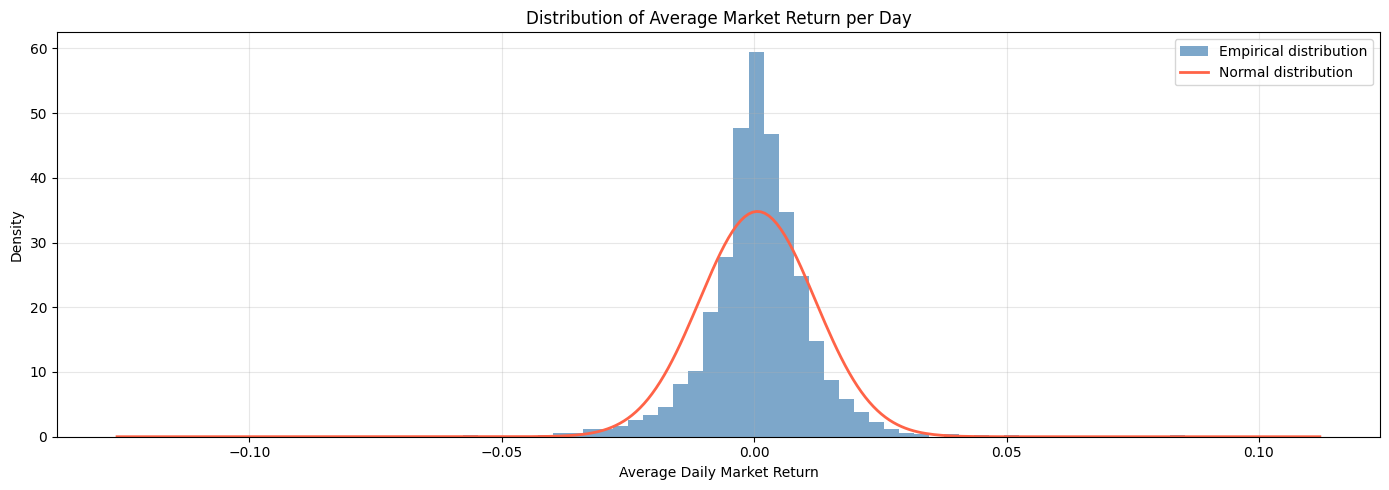

N observations: 2765
Skewness: -0.4968  (normal = 0)
Kurtosis: 17.4799  (normal = 0)


,Test,Statistic,p-value,Reject Normality?
0,Jarque-Bera,35179.4728,0.000000,Yes
1,Kolmogorov-Smirnov*,0.0941,0.000000,Yes
2,Lilliefors,0.0941,0.001000,Yes


* KS test uses estimated mean and std → may over-reject normality

SERIES 2: Average return per stock over time


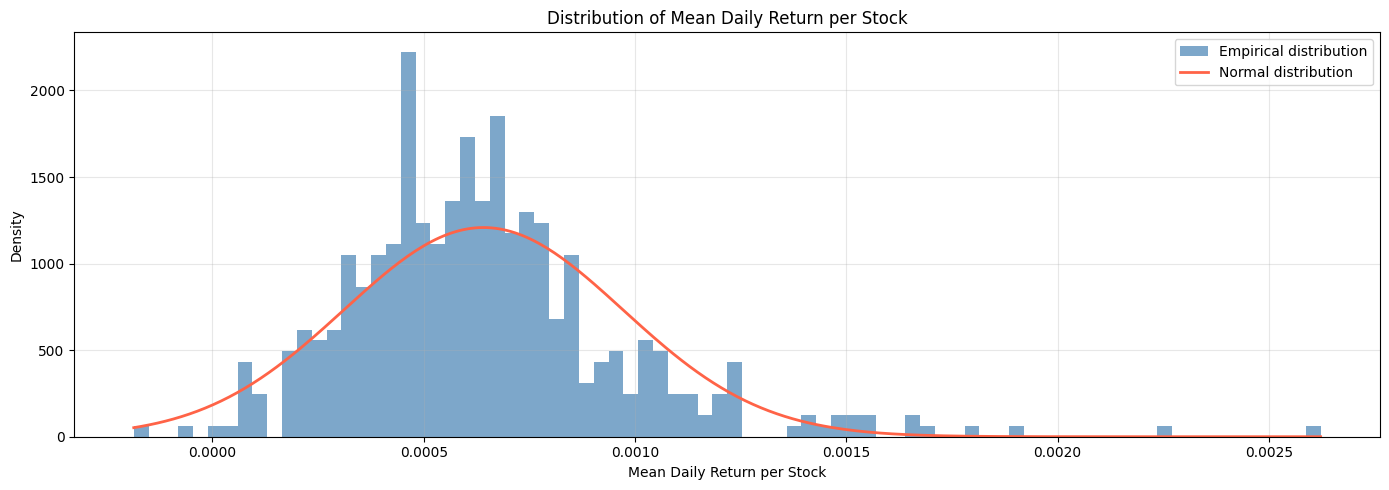

N observations: 461
Skewness: 1.3822  (normal = 0)
Kurtosis: 4.5516  (normal = 0)


,Test,Statistic,p-value,Reject Normality?
0,Jarque-Bera,532.9814,0.000000,Yes
1,Kolmogorov-Smirnov*,0.0900,0.001070,Yes
2,Lilliefors,0.0900,0.001000,Yes


* KS test uses estimated mean and std → may over-reject normality



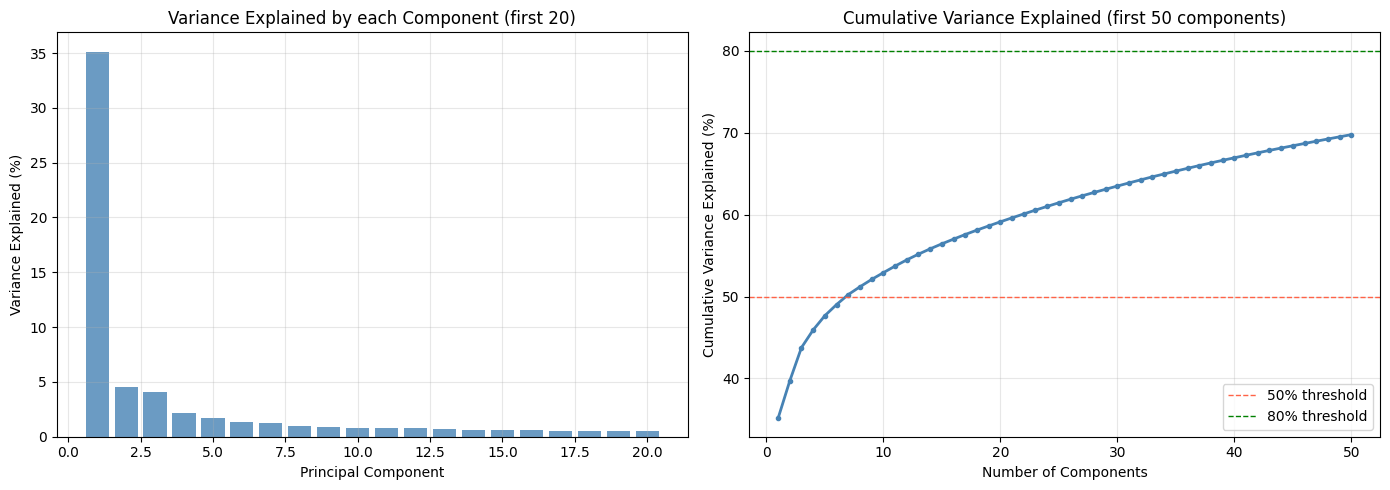

PC1 explains: 35.13% of total variance
PC2 explains: 4.56% of total variance
First 5 PCs explain: 47.66% of total variance


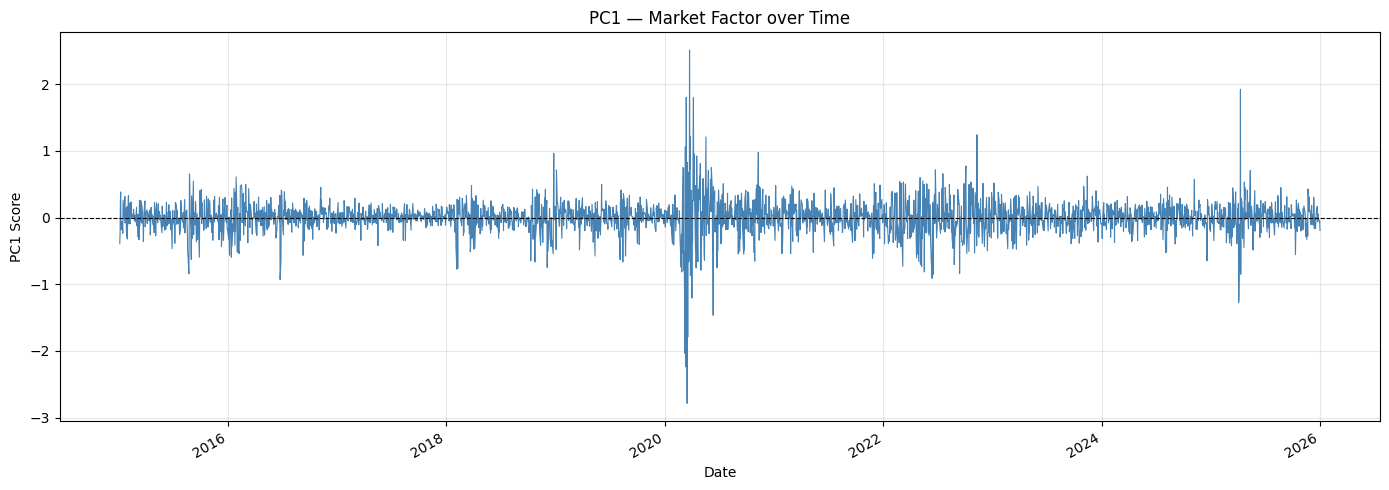

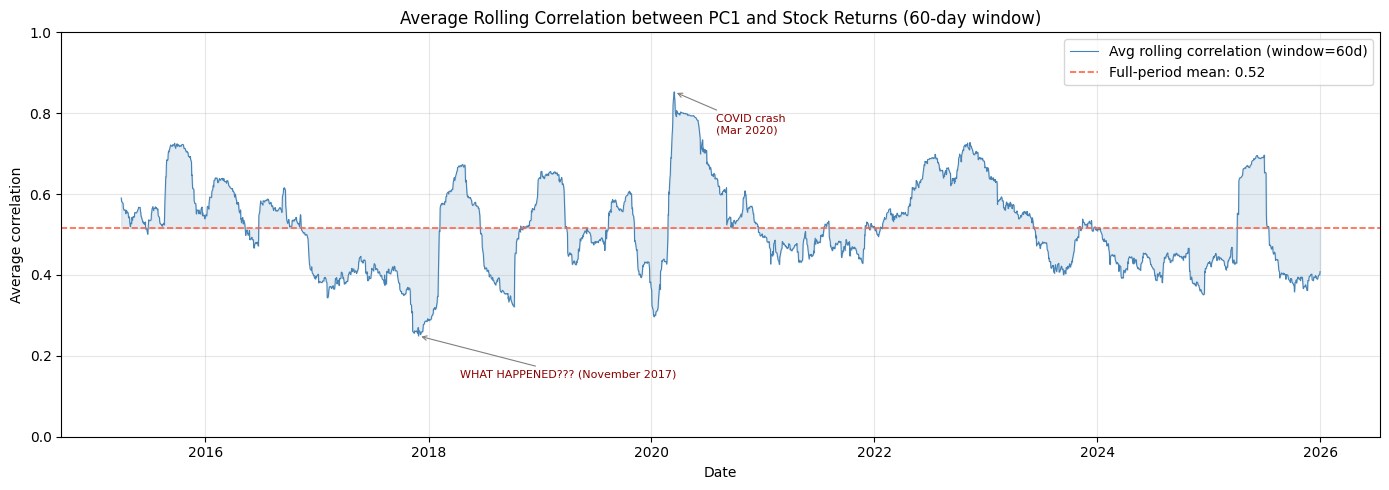

Full-period mean correlation : 0.516
Standard deviation           : 0.112
Max (most systemic day)      : 0.853  on 2020-03-16
Min (most idiosyncratic day) : 0.249  on 2017-11-29


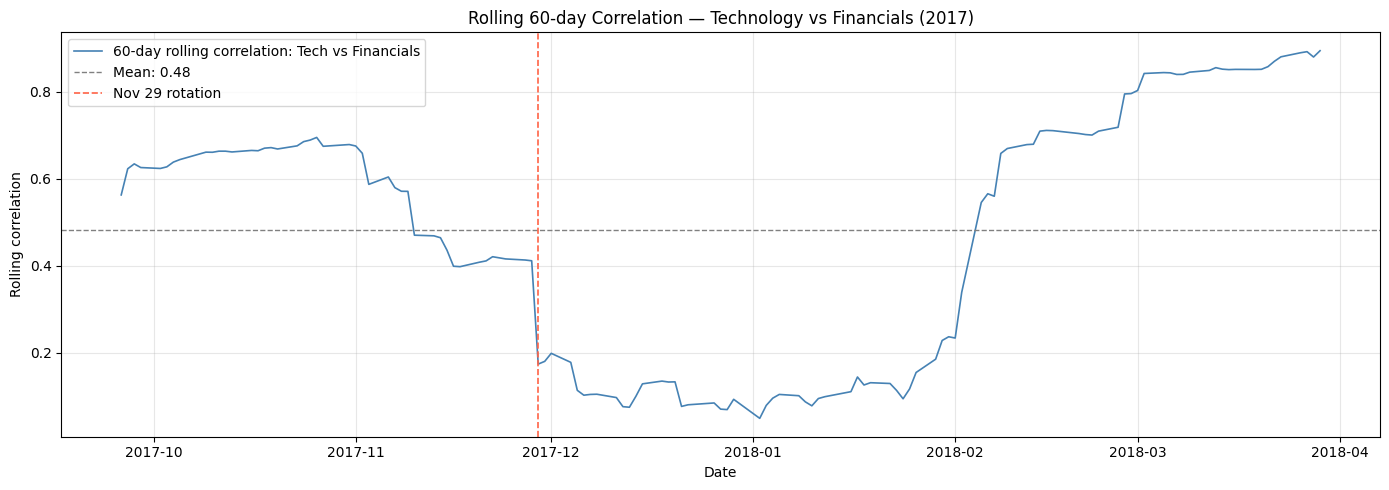

Correlation on Nov 29: 0.174
Full period mean     : 0.481
Full period min      : 0.049 on 2018-01-02
Stock with highest variance: SMCI (0.001796)


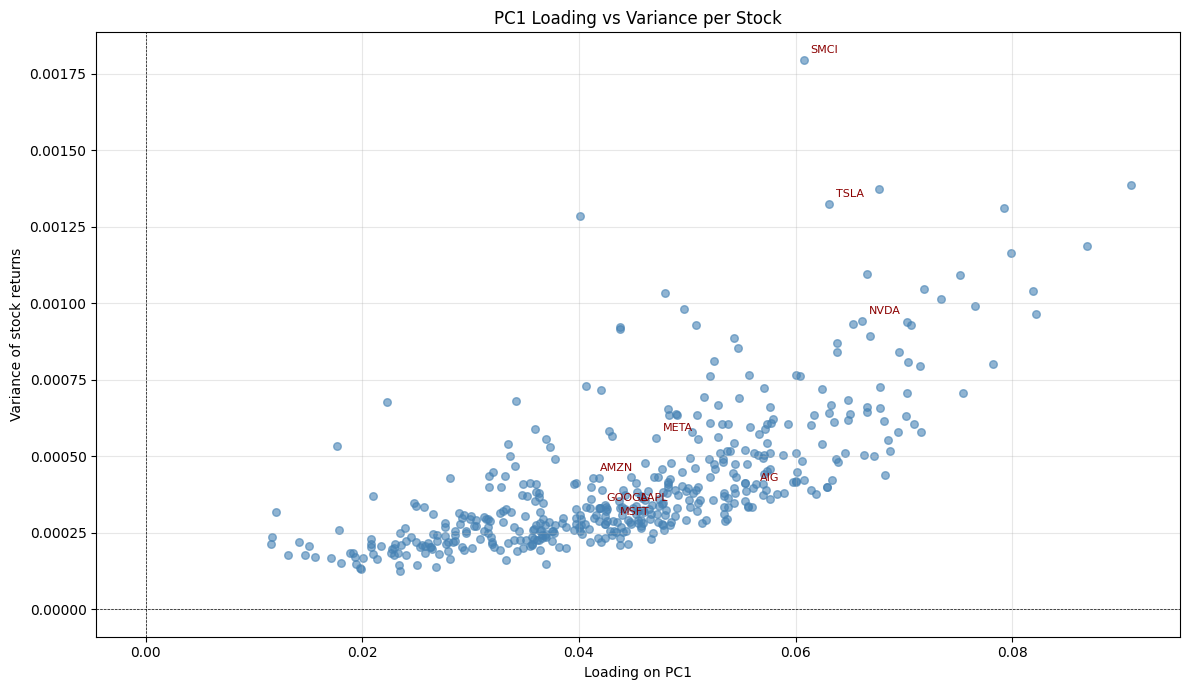


Top 5 stocks with highest PC1 loadings:
Ticker
NCLH    0.090931
CCL     0.086866
ON      0.082206
RCL     0.081876
FCX     0.079872
dtype: float64

Top 5 stocks with lowest PC1 loadings:
Ticker
CLX    0.011558
CPB    0.011637
KR     0.012040
GIS    0.013153
SJM    0.014202
dtype: float64


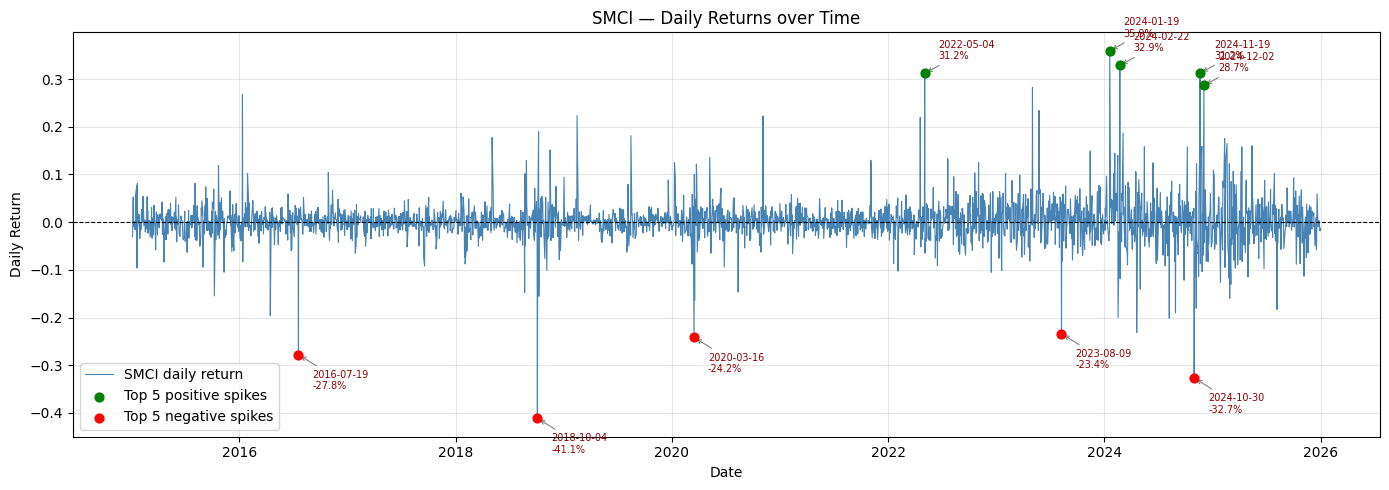

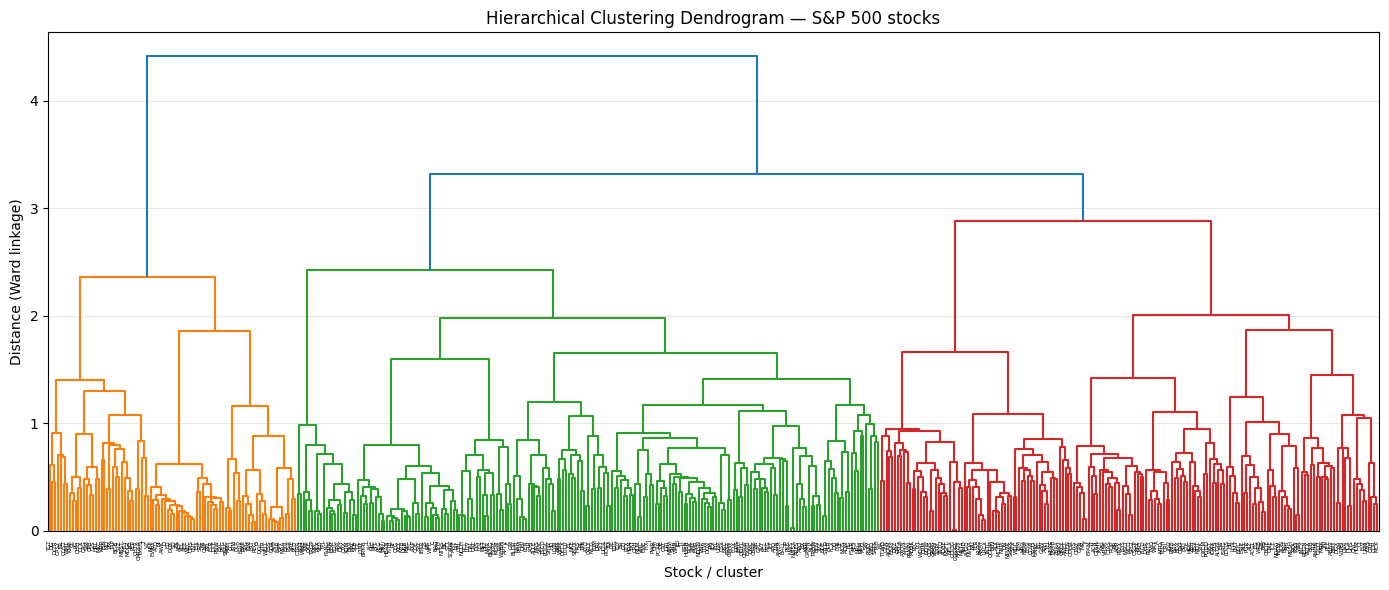

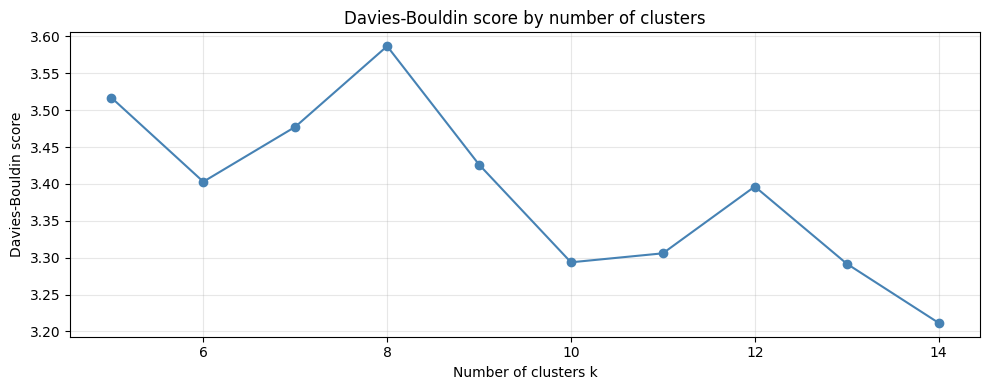

Best k by Davies-Bouldin: 14
Elbow detected at k = 8


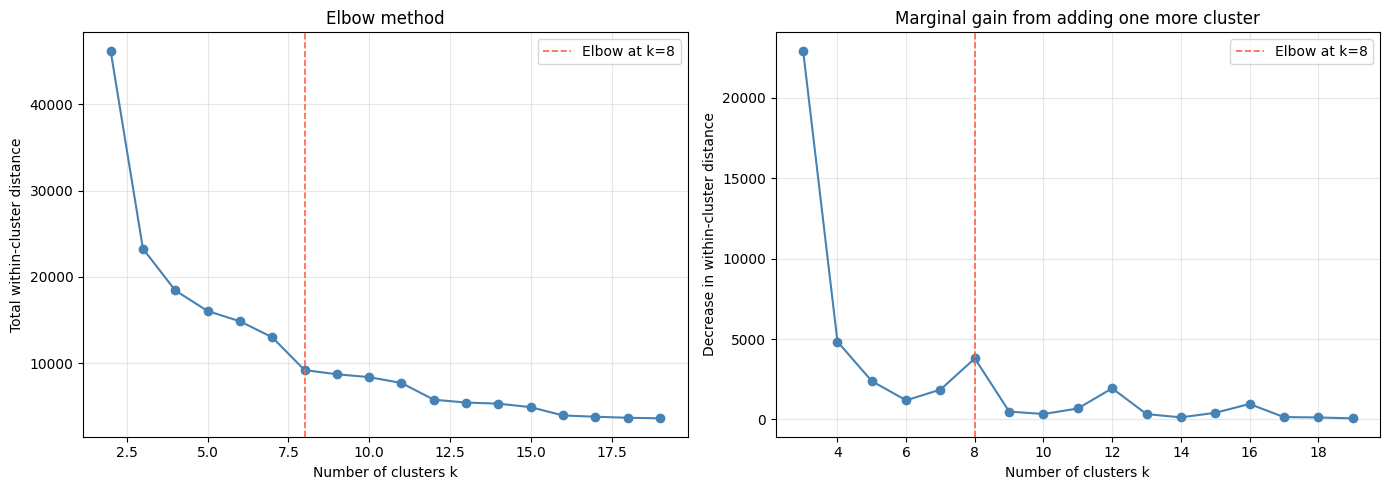


Cluster sizes (k=8):
cluster
1     35
2     51
3     21
4     54
5    127
6     67
7     53
8     53
Name: count, dtype: int64

Sector composition per cluster (k=8):


GICS Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
1,5,0,30,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,25,26
3,0,0,0,21,0,0,0,0,0,0,0
4,2,13,0,0,35,0,3,0,0,1,0
5,7,27,4,0,8,0,50,2,24,2,3
6,6,5,0,0,0,0,2,54,0,0,0
7,0,0,0,0,10,28,7,7,0,1,0
8,0,0,0,0,18,27,8,0,0,0,0


Sectors ranked by concentration across clusters (least spread first):


,Sector,N stocks,N clusters used,Dominant cluster %,Entropy (lower=better)
0,Materials,24,1,100.0,-0.000
1,Energy,21,1,100.0,-0.000
2,Utilities,29,2,89.7,0.333
3,Consumer Staples,34,2,88.2,0.362
4,Information Technology,63,3,85.7,0.486
5,Real Estate,29,4,86.2,0.545
6,Health Care,55,2,50.9,0.693
7,Consumer Discretionary,45,3,60.0,0.909
8,Industrials,70,5,71.4,0.955
9,Financials,71,4,49.3,1.219


In [ ]:
# ============================================================
# 3.1) more interesting data analysis
# ============================================================


# ============================================================
# Average return of each stock over time and over stocks
# ============================================================
stock_mean_returns = returns.mean(axis=0)    # One value per stock
market_daily_returns = returns.mean(axis=1)  # One value per day


# Helpers to plot distribution + normality tests
def plot_and_test_normality(series, title, xlabel):
    series = pd.Series(series).dropna()

    # Histogram + fitted normal
    fig, ax = plt.subplots(figsize=(14, 5))
    series.hist(
        ax=ax, bins=80, density=True,
        color='steelblue', alpha=0.7,
        label='Empirical distribution'
    )

    mu, sigma = series.mean(), series.std(ddof=1)
    x = np.linspace(series.min(), series.max(), 300)
    ax.plot(
        x, stats.norm.pdf(x, mu, sigma),
        color='tomato', linewidth=2,
        label='Normal distribution'
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Descriptive stats
    print(f"N observations: {len(series)}")
    print(f"Skewness: {series.skew():.4f}  (normal = 0)")
    print(f"Kurtosis: {series.kurt():.4f}  (normal = 0)")

    # Tests
    jb_stat, jb_pval = stats.jarque_bera(series)

    ks_stat, ks_pval = stats.kstest(
        series, 'norm', args=(mu, sigma)
    )

    lf_stat, lf_pval = lilliefors(series)

    # Summary table
    rows = [
        ['Jarque-Bera', f'{jb_stat:.4f}', f'{jb_pval:.6f}',
         'Yes' if jb_pval < 0.05 else 'No'],

        ['Kolmogorov-Smirnov*', f'{ks_stat:.4f}', f'{ks_pval:.6f}',
         'Yes' if ks_pval < 0.05 else 'No'],

        ['Lilliefors', f'{lf_stat:.4f}', f'{lf_pval:.6f}',
         'Yes' if lf_pval < 0.05 else 'No'],
    ]

    summary = pd.DataFrame(
        rows,
        columns=['Test', 'Statistic', 'p-value', 'Reject Normality?']
    )
    display(summary)

    print("* KS test uses estimated mean and std → may over-reject normality\n")

# Run for both series
# ============================================================
print("=" * 60)
print("SERIES 1: Average market return per day")
print("=" * 60)
plot_and_test_normality(
    market_daily_returns,
    title  = 'Distribution of Average Market Return per Day',
    xlabel = 'Average Daily Market Return'
)

print("=" * 60)
print("SERIES 2: Average return per stock over time")
print("=" * 60)
plot_and_test_normality(
    stock_mean_returns,
    title  = 'Distribution of Mean Daily Return per Stock',
    xlabel = 'Mean Daily Return per Stock'
)



# ============================================================
# Principal Component Analsysis
# ============================================================

# Compute PCA
pca         = PCA()
pca.fit(returns)

# Variance explained by each component
explained_variance = pca.explained_variance_ratio_

# PLOT 1: Scree plot — how many factors matter?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance explained
axes[0].bar(range(1, 21), explained_variance[:20] * 100,
            color='steelblue', alpha=0.8)
axes[0].set_title('Variance Explained by each Component (first 20)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].grid(True, alpha=0.3)

# Cumulative variance explained
axes[1].plot(range(1, 51),
             np.cumsum(explained_variance[:50]) * 100,
             color='steelblue', linewidth=2, marker='o', markersize=3)
axes[1].axhline(y=50, color='tomato', linestyle='--',
                linewidth=1, label='50% threshold')
axes[1].axhline(y=80, color='green', linestyle='--',
                linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Variance Explained (first 50 components)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 explains: {explained_variance[0]*100:.2f}% of total variance")
print(f"PC2 explains: {explained_variance[1]*100:.2f}% of total variance")
print(f"First 5 PCs explain: {sum(explained_variance[:5])*100:.2f}% of total variance")

# Extract PC1 loads
pc1_loadings = pd.Series(pca.components_[0], index=returns.columns)
scores = pca.transform(returns)
pc1_factor = pd.Series(scores[:, 0], index=returns.index)

# PLOT 2: PC1 over time
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
pc1_factor.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('PC1 — Market Factor over Time')
ax.set_ylabel('PC1 Score')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Rolling average correlation between PC1 score and stock returns
# ============================================================
window = 60

# For each day t, compute correlation between PC1 score and each stock
# over the rolling window, then average across stocks
rolling_corr = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)

for ticker in returns.columns:
    rolling_corr[ticker] = returns[ticker].rolling(window).corr(pc1_factor)

# Average across all stocks for each day
avg_rolling_corr = rolling_corr.mean(axis=1)

# PLOT 3: Average rolling correlation
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(avg_rolling_corr.index, avg_rolling_corr.values,
        color='steelblue', linewidth=0.8, label=f'Avg rolling correlation (window={window}d)')

ax.axhline(y=avg_rolling_corr.mean(), color='tomato', linewidth=1.2,
           linestyle='--', label=f'Full-period mean: {avg_rolling_corr.mean():.2f}')

# Shade the area under the curve for visual impact
ax.fill_between(avg_rolling_corr.index, avg_rolling_corr.values,
                avg_rolling_corr.mean(), alpha=0.15, color='steelblue')

# Annotate known crisis periods
crises = {
    'COVID crash\n(Mar 2020)' : '2020-03-16',
    'WHAT HAPPENED??? (November 2017)' : '2017-11-29',
    }
for label, date in crises.items():
    xval = pd.Timestamp(date)
    if xval in avg_rolling_corr.index:
        yval = avg_rolling_corr[xval]
        ax.annotate(label,
                    xy=(xval, yval),
                    xytext=(30, -30), textcoords='offset points',
                    fontsize=8, color='darkred',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_title(f'Average Rolling Correlation between PC1 and Stock Returns ({window}-day window)')
ax.set_xlabel('Date')
ax.set_ylabel('Average correlation')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Full-period mean correlation : {avg_rolling_corr.mean():.3f}")
print(f"Standard deviation           : {avg_rolling_corr.std():.3f}")
print(f"Max (most systemic day)      : {avg_rolling_corr.max():.3f}  on {avg_rolling_corr.idxmax().date()}")
print(f"Min (most idiosyncratic day) : {avg_rolling_corr.min():.3f}  on {avg_rolling_corr.idxmin().date()}")


# ============================================================
# Rolling 60-day correlation between Tech and Financials — 2017
# ============================================================

start = '2017-07-01'
end   = '2018-03-31'

# Get sector tickers
sp500_info = pd.read_csv('sp500_constituents.csv')[['Symbol', 'GICS Sector']].copy()
sp500_info['Symbol'] = sp500_info['Symbol'].str.replace('.', '-', regex=False)

tech_tickers = sp500_info[sp500_info['GICS Sector'] == 'Information Technology']['Symbol'].tolist()
fin_tickers  = sp500_info[sp500_info['GICS Sector'] == 'Financials']['Symbol'].tolist()

tech_tickers = [t for t in tech_tickers if t in returns.columns]
fin_tickers  = [t for t in fin_tickers  if t in returns.columns]

# Equal-weighted sector daily returns
tech_daily = returns.loc[start:end, tech_tickers].mean(axis=1)
fin_daily  = returns.loc[start:end, fin_tickers].mean(axis=1)

# Rolling 60-day correlation between the two sector return series
rolling_corr = tech_daily.rolling(60).corr(fin_daily)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr.index, rolling_corr.values,
        color='steelblue', linewidth=1.2,
        label='60-day rolling correlation: Tech vs Financials')

ax.axhline(rolling_corr.mean(), color='gray', linewidth=1,
           linestyle='--', label=f'Mean: {rolling_corr.mean():.2f}')

ax.axvline(pd.Timestamp('2017-11-29'), color='tomato', linewidth=1.2,
           linestyle='--', label='Nov 29 rotation')

ax.set_title('Rolling 60-day Correlation — Technology vs Financials (2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation on Nov 29: {rolling_corr.loc['2017-11-29']:.3f}")
print(f"Full period mean     : {rolling_corr.mean():.3f}")
print(f"Full period min      : {rolling_corr.min():.3f} on {rolling_corr.idxmin().date()}")


# PLOT 4: Scatter — PC1 loading vs variance per stock
# ============================================================

# Find the stock with the highest variance and add it to notable
highest_var_ticker = variance.idxmax()
print(f"Stock with highest variance: {highest_var_ticker} ({variance[highest_var_ticker]:.6f})")

notable = ['AAPL', 'MSFT', 'AIG', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA', highest_var_ticker]
notable = list(dict.fromkeys(notable))

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(pc1_loadings, variance,
           color='steelblue', alpha=0.6, s=30)

for ticker in notable:
    if ticker in pc1_loadings.index:
        ax.annotate(ticker,
                    xy=(pc1_loadings[ticker],
                        variance[ticker]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='darkred')

ax.set_title('PC1 Loading vs Variance per Stock')
ax.set_xlabel('Loading on PC1')
ax.set_ylabel('Variance of stock returns')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top and bottom 5 stocks by PC1 loading
print("\nTop 5 stocks with highest PC1 loadings:")
print(pc1_loadings.nlargest(5))

print("\nTop 5 stocks with lowest PC1 loadings:")
print(pc1_loadings.nsmallest(5))



# SMCI daily returns over time
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(returns.index, returns['SMCI'],
        color='steelblue', linewidth=0.8, label='SMCI daily return')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Mark the top 5 spikes (positive and negative) so they are easy to spot
top_pos = returns['SMCI'].nlargest(5)
top_neg = returns['SMCI'].nsmallest(5)

ax.scatter(top_pos.index, top_pos.values, color='green', zorder=5, s=40, label='Top 5 positive spikes')
ax.scatter(top_neg.index, top_neg.values, color='red',   zorder=5, s=40, label='Top 5 negative spikes')

# Annotate each spike with its date and value
for date, val in pd.concat([top_pos, top_neg]).items():
    ax.annotate(f"{date.strftime('%Y-%m-%d')}\n{val:.1%}",
                xy=(date, val),
                xytext=(10, 10 if val > 0 else -25),
                textcoords='offset points',
                fontsize=7, color='darkred',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_title('SMCI — Daily Returns over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




# ============================================================
# Hierarchical clustering on the return correlation matrix
# ============================================================

# compute correlation matrix and convert to distances
corr_matrix = returns.corr()
distance_matrix = 1 - corr_matrix # Totally suggested by AI but it makes sense. if corr = 1 distance is 0 and the maximum is reached if the two stocks move in the completely different direction

condensed_dist = squareform(distance_matrix, checks=False)  # we condense to only take unique values,also scipy needs condensed matrix to work

# hierarchical clustering (Ward minimizes within-cluster variance)
linkage_matrix = linkage(condensed_dist, method='ward')
# linkage_matrix = linkage(condensed_dist, method='average') we tried it at first following the material in A03b but it gave us very unblacend cluster (also for big number of clusters) so we used 'ward' followin AI suggestion even if ward its assuming euclidean distances which is not our case


# Plot 1: Dendrogram (truncated — showing only the top levels is cleaner)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    labels=returns.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=4,
    truncate_mode='lastp',
    p=461,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram — S&P 500 stocks')
ax.set_xlabel('Stock / cluster')
ax.set_ylabel('Distance (Ward linkage)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# Davies-Bouldin score
# ============================================================
db_scores = []
k_range = range(5, 15)

for k in k_range:
    labels = fcluster(linkage_matrix, k, criterion='maxclust')
    score = davies_bouldin_score(returns.T, labels)
    db_scores.append(score)

plt.figure(figsize=(10, 4))
plt.plot(k_range, db_scores, marker='o', color='steelblue')
plt.xlabel('Number of clusters k')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin score by number of clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmin(db_scores)]
print(f"Best k by Davies-Bouldin: {best_k}")


# Elbow method — within-cluster distance vs k
# ============================================================
k_range = range(2, 20)
within_var = []

for k in k_range:
    labels = fcluster(linkage_matrix, k, criterion='maxclust')
    wv = 0
    for c in np.unique(labels):
        members = returns.columns[labels == c]
        # sum all pairwise distances within the cluster
        sub = distance_matrix.loc[members, members].values
        wv += sub.sum() / 2
    within_var.append(wv)

# Compute the "elbow" analytically via the second derivative
deltas = np.diff(within_var)           # we simply compute how mcuh total within-cluster distance decrease by allowing for one more cluster
delta2 = np.diff(deltas)               # we compute the second difference
elbow_k = list(k_range)[np.argmin(delta2) + 2]  # +2 to account for diff offset
print(f"Elbow detected at k = {elbow_k}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw within-cluster distance
axes[0].plot(k_range, within_var, marker='o', color='steelblue', linewidth=1.5)
axes[0].axvline(x=elbow_k, color='tomato', linestyle='--',
                linewidth=1.2, label=f'Elbow at k={elbow_k}')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Total within-cluster distance')
axes[0].set_title('Elbow method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: rate of decrease (first differences)
axes[1].plot(list(k_range)[1:], np.abs(deltas), marker='o',
             color='steelblue', linewidth=1.5)
axes[1].axvline(x=elbow_k, color='tomato', linestyle='--',
                linewidth=1.2, label=f'Elbow at k={elbow_k}')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Decrease in within-cluster distance')
axes[1].set_title('Marginal gain from adding one more cluster')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cut the tree into k clusters and assign labels
k = 8
cluster_labels = fcluster(linkage_matrix, k, criterion='maxclust')
cluster_series = pd.Series(cluster_labels, index=returns.columns, name='cluster')

print(f"\nCluster sizes (k={k}):")
print(cluster_series.value_counts().sort_index())


# compare clusters to actual sectors
sp500_info = pd.read_csv('sp500_constituents.csv')[['Symbol', 'GICS Sector']].copy()
sp500_info['Symbol'] = sp500_info['Symbol'].str.replace('.', '-', regex=False)
sp500_info = sp500_info.set_index('Symbol')

cluster_df = cluster_series.to_frame().join(sp500_info, how='left')

print(f"\nSector composition per cluster (k={k}):")
sector_crosstab = pd.crosstab(cluster_df['cluster'], cluster_df['GICS Sector'])
display(sector_crosstab)


# Rank GICS sectors by how concentrated they are across clusters
# ============================================================
# For each sector, we compute how spread its stocks are across clusters
sector_concentration = []

for sector in cluster_df['GICS Sector'].dropna().unique():
    sector_stocks = cluster_df[cluster_df['GICS Sector'] == sector]
    n_stocks = len(sector_stocks)

    # how many distinct clusters does this sector appear in?
    n_clusters_used = sector_stocks['cluster'].nunique()

    # what fraction of stocks are in the dominant cluster?
    dominant_cluster_frac = sector_stocks['cluster'].value_counts().iloc[0] / n_stocks

    # entropy
    cluster_counts = sector_stocks['cluster'].value_counts(normalize=True)
    entropy = -np.sum(cluster_counts * np.log(cluster_counts))

    sector_concentration.append({
        'Sector'                : sector,
        'N stocks'              : n_stocks,
        'N clusters used'       : n_clusters_used,
        'Dominant cluster %'    : round(dominant_cluster_frac * 100, 1),
        'Entropy (lower=better)': round(entropy, 3),
    })

concentration_df = pd.DataFrame(sector_concentration)

# Sort by entropy ascending
concentration_df = concentration_df.sort_values('Entropy (lower=better)').reset_index(drop=True)

print("Sectors ranked by concentration across clusters (least spread first):")
display(concentration_df)

To finish the third section of the assignment on descriptive statistics we tried some more in-depth analysis.

## Distrubution of returns
At first we tried to plot the distribution of daily average returns in the market and then the average return for each stock observed across the full period. Two interesting facts emerge:
1. The average daily returns seem to be distributed like a normal, but actually they are not (probably because of the too fat tails and negative skewness), as the 3 tests we carried out suggested. We did not know the Lilliefors test and it was suggested by AI when we asked whether the other 2 tests were fine. In particular, we learned from it that Lilliefors is better than K-S since, when comparing the actual CDF with the hypothetical CDF, we are using as average and standard deviation for the hypothetical normal the values obtained from the data itself.
2. At the beginning we asked the AI why the distribution of daily returns was normal (wrong question since it was not). The AI told us that it was so because of the CLT. Very interestingly, the AI forgot that it cannot be so because the average daily returns are unlikely to be i.i.d.

## PCA
Secondly, we used PCA to capture the underlying returns in the market and see which stocks had the highest and the lowest loadings.
1. The big tech firms have fairly big loadings but they are not the main contributors. Most of the companies with the highest loadings are in the financial or insurance sector, like BlackRock, since those heavily depend on interest rates and the business cycle. On the other hand, Kroger and Campbell Soup (supermarkets/food) and Newmont (gold mining) are among the companies that have the lowest loadings, reflecting the idea that gold is sometimes countercyclical and that, no matter how the economy is going, you will always buy more or less the same amount of food.
2. We plot the rolling correlation between the PC1 and the returns of stocks and it is funny to see where the lowest and higher peak occured. The highest peak in correlation was in march 2020 when the pandemic started so that the decrease in return from all stocks in that month was due to this undelying common factor. On the contrty, the lowest correlation was in november 2017. We asked AI the reason for this finding and it gave us an explanation based on the change in interest rates that made resources move from the tech industry to the financial one. However, to partially check for the veridicity of such expalantion we look at the rolling correaltion of the returns between the two sector. The graph suggests that what AI told us could have been true for the months after novemer 2017 but not for the moment we are interested in since up to that moment the correlation between the two sectors remained quite high.
3. Interestingly, in the PCA of A03c AIG emerged for its high variance but modest contribution to the PCA. Here this anomaly is no more so patent since we are considering a differnt period of time. On the contrary, SMCI resulted as an outlier due to some Accounting scandals (in 2018 it failed its financial statement for 2 years in a row causing its delisting from Nasdaq) and the boom of AI later on (the company provides servers and storage systems).

## Cluster analysis
We also attempted a cluster anlysis to see whether there was any specific relation between sectors in terms of correlation of returns.
Before discussing the results, we report the fact that AI was very useful in this case providing us with better measures of distance and agglomeration methods than those we had initially implmented. It also provided us with several methods to choose the optimal number of cluster.

We tried 2 of them and in the end we chose to use 8 clusters. Indeed, Davies-Bouldin method suggested to use too many clusters (since we wanted to see whether some of the 11 sectors could have been agglomerated, using more clusters than sector was not wise). On the contrary, the elbow method suggested, as shown in the graph, that after 8 clusters there are not significant improvements in the decrease of with-in group distance.

Then, we ranked sectors based on how much dispered they were across the 8 clusters.
Interestingly, (probably this was obvious for you but not for us) materials and energy sector are among the least dispersed sectors since they depends on their own specific facotrs (especially in case of energy it is easily undersrtandble why). On the contrary the communication sector is very dispersed, why? Because there are completely different companies in it from Meta and Netflix to old communication companies.




Annual returns shape:  (11, 461)
Annual vol shape:      (11, 461)
Annual skew shape:     (11, 461)
Annual sharpe shape:   (11, 461)

Final dataset shape: (461, 44)
  → 461 stocks × 44 features
  → 11 years × 4 features per year

Train samples: 368  |  Val samples: 93


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_2 (Dense)                   │ (None, 20)             │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 3)              │            63 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 20)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 44)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,967 (7.68 KB)

 Trainable params: 1,967 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 1.0517 - r2: -0.0540 - val_loss: 1.2280 - val_r2: -0.0099 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0031 - r2: -0.0021 - val_loss: 1.1858 - val_r2: 0.0239 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9697 - r2: 0.0320 - val_loss: 1.1486 - val_r2: 0.0541 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9373 - r2: 0.0628 - val_loss: 1.1103 - val_r2: 0.0856 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9057 - r2: 0.0947 - val_loss: 1.0712 - val_r2: 0.1180 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8757 - r2: 0.1256 - val_loss: 1.0342 - val_r2: 0.1487 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8490 - r2: 0.1529 - val_loss: 1.0031 - val_r2: 0.1746 - learning_rate: 0.0010
Epoch 8/200
12/12

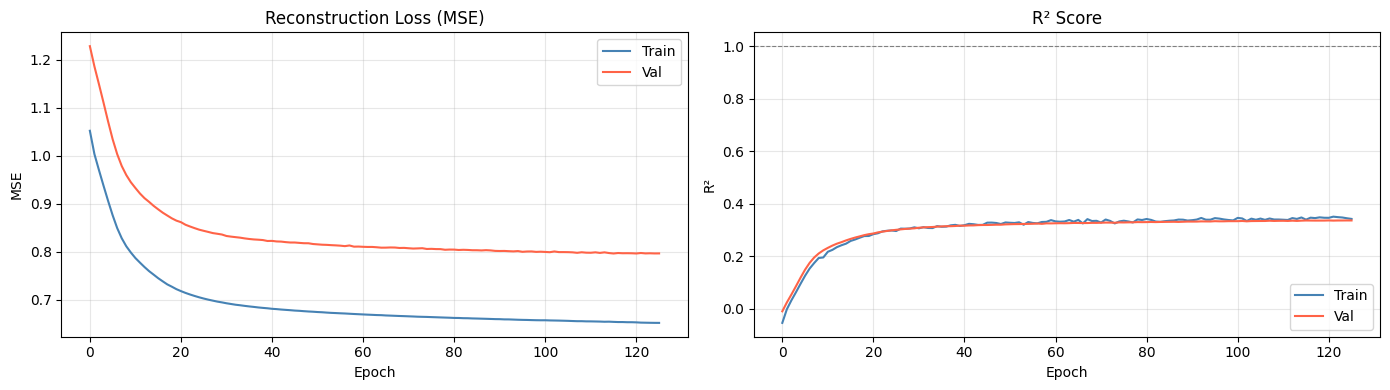

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
            z1        z2        z3
A    -0.804758  0.349818 -0.068972
AAPL -0.347603  0.595836 -1.418443
ABBV -0.287474  0.328034  0.443340


In [ ]:
# ============================================================
# GROUPING WitH AUTOENCODERS
# ============================================================

# Annual returns — compounded daily returns
annual_returns = (
    (1 + returns)
    .resample('YE')
    .prod()
    - 1
)

# Annual volatility — std of daily returns within each year
annual_vol = (
    returns
    .resample('YE')
    .std()
)

# Annual skewness
annual_skew = (
    returns
    .resample('YE')
    .apply(lambda x: x.skew())
)

# Annual Sharpe ratio
annual_sharpe = annual_returns / (annual_vol + 1e-8)

print(f"Annual returns shape:  {annual_returns.shape}")
print(f"Annual vol shape:      {annual_vol.shape}")
print(f"Annual skew shape:     {annual_skew.shape}")
print(f"Annual sharpe shape:   {annual_sharpe.shape}")


# Stack all features per stock
def to_stock_matrix(df, suffix):
    df = df.dropna()
    df.columns = [f'{col}' for col in df.columns]
    transposed = df.T
    transposed.columns = [f'{suffix}_y{i+1}' for i in range(transposed.shape[1])]
    return transposed

ret_df  = to_stock_matrix(annual_returns, 'ret')
vol_df  = to_stock_matrix(annual_vol,     'vol')
skew_df = to_stock_matrix(annual_skew,    'skew')
sh_df   = to_stock_matrix(annual_sharpe,  'sharpe')

tickers_common = ret_df.index.intersection(vol_df.index) \
                             .intersection(skew_df.index) \
                             .intersection(sh_df.index)

feature_df = pd.concat(
    [ret_df.loc[tickers_common],
     vol_df.loc[tickers_common],
     skew_df.loc[tickers_common],
     sh_df.loc[tickers_common]],
    axis=1
).dropna()

tickers = feature_df.index
data    = feature_df.values.astype(np.float32)

n_stocks, n_features = data.shape
print(f"\nFinal dataset shape: {data.shape}")
print(f"  → {n_stocks} stocks × {n_features} features")
print(f"  → {len(ret_df.columns)} years × 4 features per year")


# Split train and validatin, then standardise
Xtrain, Xval, tickers_train, tickers_val = train_test_split(
    data, tickers,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = True
)

scaler      = StandardScaler()
Xtrain      = scaler.fit_transform(Xtrain)
Xval        = scaler.transform(Xval)
data_scaled = scaler.transform(data)

print(f"\nTrain samples: {len(Xtrain)}  |  Val samples: {len(Xval)}")


# Build the autoencoder
model = Sequential(name='autoencoder')
model.add(Input(shape=(n_features,)))

model.add(Dense(20, activation='tanh', kernel_initializer=GlorotUniform(), name='enc_2'))
model.add(Dense(3,  activation='linear',                                     name='bottleneck'))
model.add(Dense(20,         activation='tanh',   kernel_initializer=GlorotUniform(), name='dec_1'))
model.add(Dense(n_features, activation='linear',                                     name='output'))

model.summary()


# Compile and train
def r2(y_true, y_pred):
    return (
        1 - tf.reduce_mean(tfp.stats.variance(y_pred - y_true))
          / tf.reduce_mean(tfp.stats.variance(y_true))
    )

model.compile(optimizer='adam', loss='mse', metrics=[r2])


early_stop = EarlyStopping(
    monitor              = 'val_loss',
    mode                 = 'min',
    patience             = 10,
    restore_best_weights = True
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    mode     = 'min',
    factor   = 0.5,
    patience = 5,
    verbose  = 1
)

history = model.fit(
    Xtrain, Xtrain,
    validation_data = (Xval, Xval),
    epochs          = 200,
    batch_size      = 32,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Best epoch:    {best_epoch}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Best val R²:   {history.history['val_r2'][best_epoch-1]:.4f}")


# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Reconstruction Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['r2'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_r2'], label='Val',   color='tomato')
axes[1].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('R² Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

encoder = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer('bottleneck').output
)

Z = encoder.predict(data_scaled)

latent_df = pd.DataFrame(
    Z,
    index=tickers,
    columns=['z1', 'z2', 'z3']
)

print(latent_df.head(3))

We attempted to repeat the cluster analysis using autoencoders, but we encountered several issues. In our initial attempts, we used a dataset consisting of daily returns for each stock over a 10-year period. However, the models trained on this dataset delivered very poor results, with R^2
 values below 0.2.

We experimented with several specifications—changing the architecture, activation functions, and adding regularization techniques such as dropout and L2—but observed only marginal improvements. We initially suspected that this might be due to the fact that the number of features (over 2,700) greatly exceeds the number of observations (fewer than 500).

However, in the dataset used in class for movie classification, a similar imbalance between variables and observations is present, yet the autoencoders performed much better. This led us to hypothesize that the poor performance in our case may instead be due to the extremely noisy nature of daily returns, which makes it difficult for the autoencoder to extract meaningful patterns.

To address this issue, we first tried using weekly returns, and then semi-annual returns, in order to reduce noise and decrease the dimensionality of the dataset. This led to visible, but still limited, improvements.

Finally, we adopted the approach presented here. Specifically, we used yearly returns and augmented them with additional statistics—such as volatility—that are derived from returns and may help the autoencoder capture more meaningful structure in the data. With this final specification, we were able to train models achieving R^2 values above 0.3.

Although the results remain below our expectations,especially when compared to our benchmark (the movie model), we believe this may be due to the inherently weaker and less stable patterns underlying the data-generating process of financial returns, which are much less consistent than those observed in movie preferences.

In all these attempts, AI was very helpful. We described to the AI the behavior of the loss function on the training and validation sets, as well as the distribution of gradients. We then brainstormed with the AI to understand the possible causes of the anomalies we observed and to identify which hyperparameter choices could help improve the model.

PLOT 1: All sectors


PLOT 2: Energy, Financials, Consumer Staples


Stocks in filtered plot: 126
Sector
Financials          71
Consumer Staples    34
Energy              21
Name: count, dtype: int64
CLUSTERING + ELBOW
Elbow detected at k      = 19
Best k by Davies-Bouldin = 2


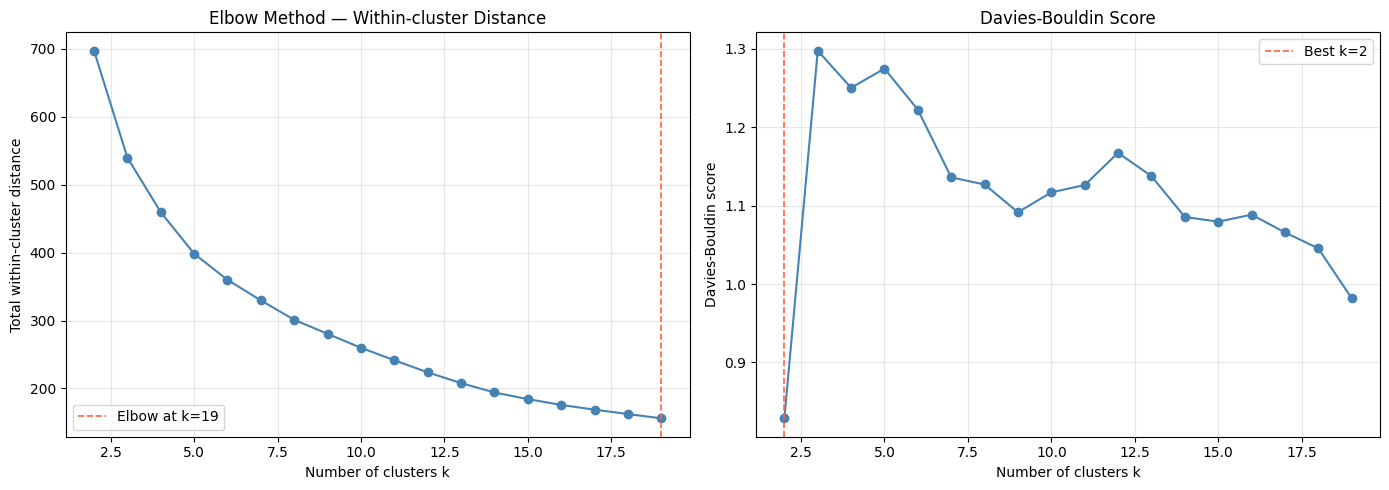

SECTOR COMPOSITION — k=8 clusters



Cluster sizes (k=8):
cluster
1      7
2     20
3     80
4     53
5    145
6    101
7     25
8     30
Name: count, dtype: int64

Sector composition per cluster (k=8):


GICS Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
1,1,0,0,1,0,0,0,5,0,0,0
2,2,1,0,12,0,0,0,0,4,0,1
3,1,5,4,7,28,3,19,7,2,3,1
4,0,7,7,0,3,14,4,3,5,7,3
5,8,6,9,0,29,12,30,11,6,12,22
6,6,13,13,0,11,16,12,18,4,7,1
7,1,5,0,0,0,1,4,13,0,0,1
8,1,8,1,1,0,9,1,6,3,0,0



Sectors ranked by concentration across clusters (least spread first):


,Sector,N stocks,N clusters used,Dominant cluster %,Entropy
0,Utilities,29,6,75.9,0.909
1,Energy,21,4,57.1,0.976
2,Financials,71,4,40.8,1.155
3,Real Estate,29,4,41.4,1.286
4,Consumer Staples,34,5,38.2,1.400
5,Industrials,70,6,42.9,1.407
6,Communication Services,20,7,40.0,1.557
7,Health Care,55,6,29.1,1.567
8,Materials,24,6,25.0,1.738
9,Consumer Discretionary,45,7,28.9,1.797


In [ ]:
# Join latent space with GICS sectors and original dataset
sp500_info = pd.read_csv('sp500_constituents.csv')[['Symbol', 'GICS Sector']].copy()
sp500_info['Symbol'] = sp500_info['Symbol'].str.replace('.', '-', regex=False)
sp500_info = sp500_info.set_index('Symbol')

z_cols  = [c for c in latent_df.columns if c.startswith('z')]
plot_df = latent_df[z_cols].join(sp500_info, how='left').reset_index()
plot_df.columns = ['Ticker'] + z_cols + ['Sector']
plot_df['Sector'] = plot_df['Sector'].fillna('Unknown')

# Helper function
def make_3d_plot(df, color_col, title):
    fig = px.scatter_3d(
        df,
        x          = 'z1',
        y          = 'z2',
        z          = 'z3',
        color      = color_col,
        hover_name = 'Ticker',
        hover_data = {'z1': ':.3f', 'z2': ':.3f', 'z3': ':.3f', 'Sector': True},
        title      = title,
        opacity    = 0.8,
        height     = 750,
    )
    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        legend = dict(title=color_col, font=dict(size=10)),
        scene  = dict(xaxis_title='z1', yaxis_title='z2', zaxis_title='z3')
    )
    return fig
Z_values = latent_df.values

# ════════════════════════════════════════════════════════════
# 1. Plot all sectors in the 3D space generated by the bottleneck
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("PLOT 1: All sectors")
print("=" * 60)

make_3d_plot(plot_df, 'Sector', 'Latent Space — All Sectors').show()

# there are too many sectors so that it is not very clear whether the 3 components are actually allowing us to seprate across sectors or not. Let's focus on 3 sectors that should be sufficiently different from each other

# ════════════════════════════════════════════════════════════
# 2. Focus on Energy, Financials, Consumer Staples only
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("PLOT 2: Energy, Financials, Consumer Staples")
print("=" * 60)

sectors_of_interest = ['Energy', 'Financials', 'Consumer Staples']
plot_df_filtered    = plot_df[plot_df['Sector'].isin(sectors_of_interest)].copy()

make_3d_plot(
    plot_df_filtered, 'Sector',
    'Latent Space — Energy, Financials & Consumer Staples'
).show()

print(f"Stocks in filtered plot: {len(plot_df_filtered)}")
print(plot_df_filtered['Sector'].value_counts())


# ════════════════════════════════════════════════════════════
# 3. Clustering + elbow curve
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("CLUSTERING + ELBOW")
print("=" * 60)


condensed = pdist(Z_values, metric='euclidean')
Z_link    = linkage(condensed, method='ward')

k_range    = range(2, 20)
within_var = []
db_scores  = []

for k in k_range:
    labels = fcluster(Z_link, k, criterion='maxclust')

    # Within-cluster distance
    wv = 0
    for c in np.unique(labels):
        members  = np.where(labels == c)[0]
        sub      = Z_values[members]
        centroid = sub.mean(axis=0)
        wv      += ((sub - centroid) ** 2).sum()
    within_var.append(wv)

    # Davies-Bouldin
    db_scores.append(davies_bouldin_score(Z_values, labels))

# Elbow detection
deltas  = np.diff(within_var)
delta2  = np.diff(deltas)
elbow_k = list(k_range)[np.argmin(delta2) + 2]
best_k_db = list(k_range)[np.argmin(db_scores)]

print(f"Elbow detected at k      = {elbow_k}")
print(f"Best k by Davies-Bouldin = {best_k_db}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, within_var, marker='o', color='steelblue', linewidth=1.5)
axes[0].axvline(x=elbow_k, color='tomato', linestyle='--',
                linewidth=1.2, label=f'Elbow at k={elbow_k}')
axes[0].set_title('Elbow Method — Within-cluster Distance')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Total within-cluster distance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, db_scores, marker='o', color='steelblue', linewidth=1.5)
axes[1].axvline(x=best_k_db, color='tomato', linestyle='--',
                linewidth=1.2, label=f'Best k={best_k_db}')
axes[1].set_title('Davies-Bouldin Score')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Davies-Bouldin score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# 4. Cut at k=8 sector composition + concentration analysis
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("SECTOR COMPOSITION — k=8 clusters")
print("=" * 60)

k = 8
cluster_labels = fcluster(Z_link, k, criterion='maxclust')

# Attach cluster labels to plot_df for 3D visualisation
plot_df['AE Cluster'] = cluster_labels.astype(str)

make_3d_plot(
    plot_df, 'AE Cluster',
    f'Latent Space — {k} Clusters (Ward linkage)'
).show()

# Attach cluster labels to ticker index for sector analysis
cluster_series = pd.Series(cluster_labels, index=latent_df.index, name='cluster')
cluster_df     = cluster_series.to_frame().join(sp500_info, how='left')

print(f"\nCluster sizes (k={k}):")
print(cluster_series.value_counts().sort_index())

print(f"\nSector composition per cluster (k={k}):")
sector_crosstab = pd.crosstab(cluster_df['cluster'], cluster_df['GICS Sector'])
display(sector_crosstab)

# Sector concentration analysis
sector_concentration = []

for sector in cluster_df['GICS Sector'].dropna().unique():
    sector_stocks = cluster_df[cluster_df['GICS Sector'] == sector]
    n_stocks      = len(sector_stocks)

    n_clusters_used       = sector_stocks['cluster'].nunique()
    dominant_cluster_frac = sector_stocks['cluster'].value_counts().iloc[0] / n_stocks

    cluster_counts = sector_stocks['cluster'].value_counts(normalize=True)
    entropy        = -np.sum(cluster_counts * np.log(cluster_counts))

    sector_concentration.append({
        'Sector'                 : sector,
        'N stocks'               : n_stocks,
        'N clusters used'        : n_clusters_used,
        'Dominant cluster %'     : round(dominant_cluster_frac * 100, 1),
        'Entropy' : round(entropy, 3),
    })

concentration_df = pd.DataFrame(sector_concentration)
concentration_df = concentration_df.sort_values('Entropy').reset_index(drop=True)

print("\nSectors ranked by concentration across clusters (least spread first):")
display(concentration_df)


Since we applied our autoencoder to a dataset with a relatively small number of features per observation (due to our decision to significantly reduce dimensionality), we were able to train a model with only three neurons in the bottleneck layer. This allowed us to easily visualize the observations in a three-dimensional space based on their values along these three latent components.

Plotting the stocks and coloring them by sector suggests that the autoencoder was indeed able to capture some underlying factors that are partially related to economic sectors.

We also attempted to determine the optimal number of clusters using the same two methods as before (elbow method and Davies-Bouldin index). Although these methods did not indicate that k=8 was optimal, we nevertheless chose to retain 8 clusters in order to facilitate comparison with the previous clustering results.

Interestingly, this new approach produces clusters that align less closely with the existing sector classification. Moreover, when ranking sectors by entropy, we observe a different pattern compared to the previous method. In particular, while Energy and Utilities still exhibit relatively low entropy (indicating concentration within clusters), Materials displays significantly higher entropy.

At this stage, we are not able to definitively determine which of the two clustering approaches should be preferred. Although the performance metrics of the autoencoder are not particularly strong, it is important to note that the distance measures used in the two clustering methods are fundamentally different. In the first approach, clustering is entirely based on correlations of returns between stocks. In the second approach, clustering is based on latent representations that reflect broader underlying characteristics, such as aggregated return dynamics and related features that should have been captured by the autoencoder.

For this reason, both methods may be considered valid, despite producing quite different clustering structures. However, we remain somewhat skeptical of the second method, since in several attempts we observed that simply changing the architecture of the neural network resulted in very different cluster compositions.

In [7]:
# ============================================================
# 4) Divide the sample in train and test subsamples
# ============================================================

np.random.seed(42)
selected_stocks = np.random.choice(returns.columns, size=100, replace=False)
returns_subset  = returns[selected_stocks]

# We do not split at random but based on position since the data are time-based
split_index   = int(len(returns_subset) * 0.8)
split_date    = returns_subset.index[split_index]
returns_train = returns_subset.iloc[:split_index]
returns_test  = returns_subset.iloc[split_index:]

print(f"Split date:   {split_date.strftime('%Y-%m-%d')}")
print(f"Train sample: {returns_train.shape[0]} days")
print(f"Test sample:  {returns_test.shape[0]} days")


NameError: name 'returns' is not defined

In the following sections we tried to construct the optimal portfolio satisfying the conditions indicated in the assignment. We did not know how to optimize the MAD, so we asked AI.

We had to be more cautious than before with the code generated in these steps. In order to easily find an optimization process, the AI initially suggested methods that included several approximations of the true parameters we were interested in. Indeed, the main issue in this optimization is that the median is a somewhat awkward value to optimize since, differently from the mean, it does not change smoothly when the weights change.

The first solutions offered by the AI used an oversimplification of the problem, exploiting several approximations that in the end led to quite different values of the median of the portfolio compared to the target value. We discarded them for this reason.


In the end, two processes were chosen and are displayed below.

1. The first one gives us a lower MAD portfolio and is also computationally easier and quicker, since we rely on an approximation of the true value of the median return (and also the MAD) to make the problem linear. However, this implies that the actual median value of the porfolio is not exactly the desired one.

   $m_p \approx \sum_i w_i \cdot \text{median}(r_i)$  
   $\min_w \frac{1}{T} \sum_t |(Rw)_t - m_p|$

2. The second option instead uses softmax to minimize a loss function that is the sum of the MAD of the portfolio and the difference between its median value and the target median, to which we add a penalty.

   More precisely, the second method minimizes  
   $L(w) = \text{MAD}(w) + \lambda \cdot |\text{median}(Rw) - m_{\text{target}}|$,  
   where  
   $\text{MAD}(w) = \frac{1}{T} \sum_t |(Rw)_t - \text{median}(Rw)|$  
   and $\lambda$ is a penalty parameter that controls how strongly we enforce the target median.

   This second method is computationally more intensive and indeed for all 10 portolios the maximization stopped because it hit the maximum number of iteration not and optimal MAD. To overcome this problem we increased the number of allowed interaction. However, even in this case, the resulting portfolios have slighlty higher MAD than those obtained with the linear optimization. On the other hand, the very high penalty imposed on diverging from the target median allows us to get portfolios that have in most case exactly the median value we wanted.
    

In [6]:
# ============================================================
# 5) Portfolio construction
# ============================================================


# Target medians
stock_medians  = returns_train.median()
min_median     = stock_medians.min()
max_median     = stock_medians.max()
target_medians = np.linspace(min_median, max_median, 10)

print(f"\nMin stock median: {min_median:.6f}")
print(f"Max stock median: {max_median:.6f}")


# *******************************************************
# 1st Method: CVXPY (linear proxy method)
# *******************************************************

R    = returns_train.values
T, N = R.shape

def min_mad_portfolio(R, target_median):

    T, N = R.shape
    w    = cp.Variable(N)   # we store portfolio weights here
    u    = cp.Variable(T)   # we store each of deviation to then calculate the MAD

    # Actual portfolio return series
    port_returns = R @ w

    # Since the true median is not linear one easy way to optimize the portfolio is to find a linear way to approximate it
    stock_med    = np.median(R, axis=0)
    port_median  = stock_med @ w         # we aproximate median(Rw) with w * median(R)

    # Objective: minimize TRUE portfolio MAD ---
    # MAD = mean(|r_t - median_portfolio|)
    objective   = cp.Minimize(cp.sum(u) / T)

    # --- Constraints ---
    constraints = [
        u >= port_returns - port_median,    # u absorbs positive deviations
        u >= -(port_returns - port_median),  # u absorbs negative deviations
        u >= 0,
        cp.sum(w) == 1,                   # Weights sum to 1
        w >= 0,                           # No short selling in this case but we will also try to allow shortselling
        port_median == target_median      # the aproximation of the median will be used in the optimization
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.HIGHS)
    return w.value, prob.value

# --- Run optimization for all 10 targets ---
results_train = []

for i, target in enumerate(target_medians):
    print(f"Optimizing portfolio {i+1}/10 — target median: {target:.6f}")

    weights, mad_val = min_mad_portfolio(R, target)

    if weights is not None:
        port_returns = R @ weights
        opt_median   = np.median(port_returns)
        opt_mad      = np.mean(np.abs(port_returns - opt_median))

        results_train.append({
            'target_median': target,
            'median'       : opt_median,
            'mad'          : opt_mad,
            'weights'      : weights
        })
        print(f"  ✓ median: {opt_median:.6f}, MAD: {opt_mad:.6f}")
    else:
        print(f"  ✗ Failed")

frontier_train = pd.DataFrame([{
    'median': r['median'],
    'mad'   : r['mad']
} for r in results_train])

# Plot
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(frontier_train['median'], frontier_train['mad'],
            color='steelblue', s=100, zorder=5, label='Train portfolios')
plt.plot(frontier_train['median'], frontier_train['mad'],
         color='steelblue', linewidth=1.5, linestyle='--')
plt.xlabel('Portfolio Median Daily Return')
plt.ylabel('Portfolio MAD')
plt.title('Minimum MAD Frontier — Train Sample')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

results_train_proxy = results_train.copy()
frontier_train_proxy = frontier_train.copy()

NameError: name 'returns_train' is not defined

In [5]:
# ============================================================
# Step 5: Proxy portfolio and multistart penalized portfolio
# with caching in results/
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.optimize import minimize

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
R_full = returns_train.values
T_full, N = R_full.shape

stock_medians  = returns_train.median()
min_median     = stock_medians.min()
max_median     = stock_medians.max()
target_medians = np.linspace(min_median, max_median, 10)

print(f"Min stock median: {min_median:.6f}")
print(f"Max stock median: {max_median:.6f}")

# ------------------------------------------------------------
# Results directory and cache file names
# ------------------------------------------------------------
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

WEIGHTS_FILE      = RESULTS_DIR / "warmstart_multistart_softmax_portfolio_weights.csv"
FRONTIER_FILE     = RESULTS_DIR / "warmstart_multistart_softmax_frontier_summary.csv"
DIAGNOSTICS_FILE  = RESULTS_DIR / "warmstart_multistart_diagnostics.csv"
LAMBDA_FILE       = RESULTS_DIR / "warmstart_multistart_lambda_insample_diagnostics.csv"
COMPARISON_FILE   = RESULTS_DIR / "warmstart_multistart_homogeneous_comparison.csv"
PROXY_FILE        = RESULTS_DIR / "warmstart_multistart_proxy_summary.csv"

# ------------------------------------------------------------
# Tuning parameters
# ------------------------------------------------------------
lambda_grid = [10, 30, 100, 300, 1000, 3000, 10000]
median_tolerance = 1e-5

# ------------------------------------------------------------
# Proxy optimization
# ------------------------------------------------------------
def min_abs_dev_around_target(R, target_median):
    T, N = R.shape

    w = cp.Variable(N)
    u = cp.Variable(T)

    port_returns = R @ w

    objective = cp.Minimize(cp.sum(u) / T)
    constraints = [
        u >= port_returns - target_median,
        u >= -(port_returns - target_median),
        u >= 0,
        cp.sum(w) == 1,
        w >= 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.HIGHS)

    return w.value, prob.value, prob.status

# ------------------------------------------------------------
# Portfolio utilities
# ------------------------------------------------------------
def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()

def weights_to_softmax_logits(w, eps=1e-12):
    w = np.asarray(w, dtype=float)
    w = np.clip(w, eps, None)
    w = w / w.sum()
    return np.log(w)

def compute_true_mad(port_returns):
    med = np.median(port_returns)
    mad = np.mean(np.abs(port_returns - med))
    return med, mad

def compute_target_mad(port_returns, target_median):
    return np.mean(np.abs(port_returns - target_median))

def compute_portfolio_stats_from_weights(R, w, target_median=None):
    port_returns = R @ w
    median, mad = compute_true_mad(port_returns)

    out = {
        "port_returns": port_returns,
        "median": median,
        "mad": mad
    }

    if target_median is not None:
        out["target_mad"] = compute_target_mad(port_returns, target_median)

    return out

def portfolio_stats_from_z(z, R, target_median=None):
    w = softmax(z)
    stats = compute_portfolio_stats_from_weights(R, w, target_median=target_median)
    return w, stats

def penalized_objective(z, R, target_median, penalty):
    _, stats = portfolio_stats_from_z(z, R, target_median=target_median)
    median_error = abs(stats["median"] - target_median)
    return stats["mad"] + penalty * median_error

# ------------------------------------------------------------
# Multistart local optimization
# ------------------------------------------------------------
def generate_multiple_starts(z_proxy, n_starts=8, perturb_scale=2.0, seed=42):
    rng = np.random.default_rng(seed)
    starts = [z_proxy.copy()]

    for _ in range(n_starts - 1):
        eps = rng.normal(loc=0.0, scale=perturb_scale, size=z_proxy.shape)
        z_new = z_proxy + eps
        z_new = z_new - np.mean(z_new)
        starts.append(z_new)

    return starts

def run_one_local_start(z0, R, target_median, penalty, maxiter=20000):
    result = minimize(
        fun=penalized_objective,
        x0=z0,
        args=(R, target_median, penalty),
        method="Powell",
        options={
            "maxiter": maxiter,
            "xtol": 1e-7,
            "ftol": 1e-7
        }
    )

    z_star = result.x
    w_star, stats = portfolio_stats_from_z(z_star, R, target_median=target_median)

    return {
        "weights": w_star,
        "z_star": z_star,
        "median": stats["median"],
        "mad": stats["mad"],
        "target_mad": stats["target_mad"],
        "median_error": stats["median"] - target_median,
        "abs_median_error": abs(stats["median"] - target_median),
        "objective_value": result.fun,
        "success": result.success,
        "message": result.message
    }

def select_best_result(candidates):
    return sorted(
        candidates,
        key=lambda d: (
            d["abs_median_error"],
            d["target_mad"],
            d["mad"],
            d["objective_value"]
        )
    )[0]

def solve_true_mad_portfolio_multistart(
    R,
    target_median,
    z_proxy,
    penalty,
    maxiter=20000,
    n_starts=8,
    perturb_scale=2.0,
    seed=42
):
    starts = generate_multiple_starts(
        z_proxy=z_proxy,
        n_starts=n_starts,
        perturb_scale=perturb_scale,
        seed=seed
    )

    all_results = []
    for k, z0 in enumerate(starts):
        res = run_one_local_start(
            z0=z0,
            R=R,
            target_median=target_median,
            penalty=penalty,
            maxiter=maxiter
        )
        res["start_id"] = k
        res["is_proxy_start"] = (k == 0)
        all_results.append(res)

    best_result = select_best_result(all_results)
    best_result["all_start_results"] = all_results
    return best_result

# ------------------------------------------------------------
# Lambda selection
# ------------------------------------------------------------
def choose_lambda_for_target(
    R,
    target_median,
    lambda_grid,
    median_tolerance=1e-5,
    n_starts=20,
    perturb_scale=2.5,
    maxiter=20000,
    seed=42
):
    proxy_w, proxy_obj, proxy_status = min_abs_dev_around_target(R, target_median)

    if proxy_w is None or proxy_status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Proxy optimization failed for target {target_median:.6f}")

    proxy_w = np.maximum(proxy_w, 0.0)
    proxy_w = proxy_w / proxy_w.sum()
    z_proxy = weights_to_softmax_logits(proxy_w)

    lambda_results = []
    for j, lam in enumerate(lambda_grid):
        fit_res = solve_true_mad_portfolio_multistart(
            R=R,
            target_median=target_median,
            z_proxy=z_proxy,
            penalty=lam,
            maxiter=maxiter,
            n_starts=n_starts,
            perturb_scale=perturb_scale,
            seed=seed + j
        )

        lambda_results.append({
            "lambda": lam,
            "median": fit_res["median"],
            "mad": fit_res["mad"],
            "target_mad": fit_res["target_mad"],
            "median_error": fit_res["median_error"],
            "abs_median_error": fit_res["abs_median_error"],
            "success": fit_res["success"],
            "weights": fit_res["weights"],
            "z_star": fit_res["z_star"],
            "start_id": fit_res["start_id"],
            "is_proxy_start": fit_res["is_proxy_start"],
            "objective_value": fit_res["objective_value"],
            "message": fit_res["message"],
            "all_start_results": fit_res["all_start_results"]
        })

    feasible = [d for d in lambda_results if d["abs_median_error"] <= median_tolerance]

    if feasible:
        chosen = sorted(
            feasible,
            key=lambda d: (d["target_mad"], d["mad"], d["lambda"])
        )[0]
    else:
        chosen = sorted(
            lambda_results,
            key=lambda d: (
                d["abs_median_error"],
                d["target_mad"],
                d["mad"],
                d["lambda"]
            )
        )[0]

    return chosen, lambda_results, proxy_w, proxy_obj

# ------------------------------------------------------------
# Try loading cached results first
# ------------------------------------------------------------
cache_available = all(path.exists() for path in [
    WEIGHTS_FILE, FRONTIER_FILE, DIAGNOSTICS_FILE, LAMBDA_FILE, COMPARISON_FILE, PROXY_FILE
])

if cache_available:
    print("\nLoading cached results from results/ ...")

    weights_df = pd.read_csv(WEIGHTS_FILE, index_col=0)
    frontier_train_true = pd.read_csv(FRONTIER_FILE)
    multistart_log_df = pd.read_csv(DIAGNOSTICS_FILE)
    lambda_insample_df = pd.read_csv(LAMBDA_FILE)
    comparison_df = pd.read_csv(COMPARISON_FILE)
    proxy_summary = pd.read_csv(PROXY_FILE)

    # Rebuild results_train_true in the format expected by later cells
    results_train_true = []
    for _, row in frontier_train_true.iterrows():
        col_name = f"target_{row['target_median']:.6f}"
        if col_name not in weights_df.columns:
            raise KeyError(f"Missing weight column {col_name} in cached weights file.")

        results_train_true.append({
            "weights": weights_df[col_name].values,
            "z_star": None,
            "median": row["median"],
            "mad": row["mad"],
            "target_mad": row["target_mad"],
            "median_error": row["median_error"],
            "target_median": row["target_median"],
            "chosen_lambda": row["chosen_lambda"],
            "objective_value": np.nan,
            "success": True,
            "message": "loaded from cache",
            "best_start_id": row["best_start_id"],
            "best_is_proxy_start": row["best_is_proxy_start"]
        })

    # Rebuild proxy_results in the format expected by later cells
    proxy_results = []
    for _, row in proxy_summary.iterrows():
        target = row["target_median"]
        proxy_w, proxy_obj, proxy_status = min_abs_dev_around_target(R_full, target)

        if proxy_w is None or proxy_status not in ["optimal", "optimal_inaccurate"]:
            raise RuntimeError(f"Failed to reconstruct proxy weights for target {target:.6f}")

        proxy_w = np.maximum(proxy_w, 0.0)
        proxy_w = proxy_w / proxy_w.sum()

        proxy_results.append({
            "target_median": target,
            "proxy_obj": proxy_obj,
            "proxy_true_median": row["proxy_true_median"],
            "proxy_true_mad": row["proxy_true_mad"],
            "proxy_target_mad": row["proxy_target_mad"],
            "proxy_median_error": row["proxy_median_error"],
            "proxy_abs_median_error": row["proxy_abs_median_error"],
            "proxy_weights": proxy_w
        })

else:
    print("\nNo cached results found in results/. Running optimization ...")

    # --------------------------------------------------------
    # Main loop
    # --------------------------------------------------------
    results_train_true = []
    proxy_results = []
    all_multistart_logs = []
    lambda_insample_logs = []

    for i, target in enumerate(target_medians):
        print(f"\nTarget {i+1}/10 — target median: {target:.6f}")

        chosen_res, lambda_results, proxy_w, proxy_obj = choose_lambda_for_target(
            R=R_full,
            target_median=target,
            lambda_grid=lambda_grid,
            median_tolerance=median_tolerance,
            n_starts=20,
            perturb_scale=2.5,
            maxiter=20000,
            seed=1000 + i
        )

        chosen_lambda = chosen_res["lambda"]

        for d in lambda_results:
            lambda_insample_logs.append({
                "target_median": target,
                "lambda": d["lambda"],
                "median": d["median"],
                "mad": d["mad"],
                "target_mad": d["target_mad"],
                "median_error": d["median_error"],
                "abs_median_error": d["abs_median_error"],
                "is_chosen_lambda": (d["lambda"] == chosen_lambda)
            })

        proxy_stats = compute_portfolio_stats_from_weights(R_full, proxy_w, target_median=target)

        proxy_results.append({
            "target_median": target,
            "proxy_obj": proxy_obj,
            "proxy_true_median": proxy_stats["median"],
            "proxy_true_mad": proxy_stats["mad"],
            "proxy_target_mad": proxy_stats["target_mad"],
            "proxy_median_error": proxy_stats["median"] - target,
            "proxy_abs_median_error": abs(proxy_stats["median"] - target),
            "proxy_weights": proxy_w
        })

        for d in chosen_res["all_start_results"]:
            all_multistart_logs.append({
                "target_median": target,
                "chosen_lambda": chosen_lambda,
                "start_id": d["start_id"],
                "is_proxy_start": d["is_proxy_start"],
                "median": d["median"],
                "mad": d["mad"],
                "target_mad": d["target_mad"],
                "median_error": d["median_error"],
                "abs_median_error": d["abs_median_error"],
                "objective_value": d["objective_value"],
                "success": d["success"]
            })

        results_train_true.append({
            "weights": chosen_res["weights"],
            "z_star": chosen_res["z_star"],
            "median": chosen_res["median"],
            "mad": chosen_res["mad"],
            "target_mad": chosen_res["target_mad"],
            "median_error": chosen_res["median_error"],
            "target_median": target,
            "chosen_lambda": chosen_lambda,
            "objective_value": chosen_res["objective_value"],
            "success": chosen_res["success"],
            "message": chosen_res["message"],
            "best_start_id": chosen_res["start_id"],
            "best_is_proxy_start": chosen_res["is_proxy_start"]
        })

        print(f"lambda = {chosen_lambda}")
        print(f"median = {chosen_res['median']:.12f}")
        print(f"MAD = {chosen_res['mad']:.6f}")
        print(f"TargetMAD = {chosen_res['target_mad']:.6f}")

    # --------------------------------------------------------
    # Summary tables
    # --------------------------------------------------------
    frontier_train_true = pd.DataFrame([
        {
            "target_median": r["target_median"],
            "median": r["median"],
            "mad": r["mad"],
            "target_mad": r["target_mad"],
            "median_error": r["median_error"],
            "abs_median_error": abs(r["median_error"]),
            "chosen_lambda": r["chosen_lambda"],
            "best_start_id": r["best_start_id"],
            "best_is_proxy_start": r["best_is_proxy_start"]
        }
        for r in results_train_true
    ]).sort_values("target_median").reset_index(drop=True)

    proxy_summary = pd.DataFrame([
        {
            "target_median": r["target_median"],
            "proxy_true_median": r["proxy_true_median"],
            "proxy_true_mad": r["proxy_true_mad"],
            "proxy_target_mad": r["proxy_target_mad"],
            "proxy_median_error": r["proxy_median_error"],
            "proxy_abs_median_error": r["proxy_abs_median_error"]
        }
        for r in proxy_results
    ]).sort_values("target_median").reset_index(drop=True)

    multistart_log_df = pd.DataFrame(all_multistart_logs).sort_values(
        ["target_median", "start_id"]
    ).reset_index(drop=True)

    lambda_insample_df = pd.DataFrame(lambda_insample_logs).sort_values(
        ["target_median", "lambda"]
    ).reset_index(drop=True)

    comparison_df = proxy_summary.merge(
        frontier_train_true,
        on="target_median",
        how="inner",
        suffixes=("_proxy", "_true")
    )

    print("\nFinal training frontier:")
    print(frontier_train_true[[
        "target_median",
        "median",
        "mad",
        "target_mad",
        "abs_median_error",
        "chosen_lambda"
    ]])

    # --------------------------------------------------------
    # Save outputs to results/
    # --------------------------------------------------------
    weights_df = pd.DataFrame(
        {f"target_{r['target_median']:.6f}": r["weights"] for r in results_train_true},
        index=returns_train.columns
    )
    weights_df.to_csv(WEIGHTS_FILE)

    frontier_train_true.to_csv(FRONTIER_FILE, index=False)
    multistart_log_df.to_csv(DIAGNOSTICS_FILE, index=False)
    lambda_insample_df.to_csv(LAMBDA_FILE, index=False)
    comparison_df.to_csv(COMPARISON_FILE, index=False)
    proxy_summary.to_csv(PROXY_FILE, index=False)

    print("\nSaved results to results/:")
    print(f"  {WEIGHTS_FILE.name}")
    print(f"  {FRONTIER_FILE.name}")
    print(f"  {DIAGNOSTICS_FILE.name}")
    print(f"  {LAMBDA_FILE.name}")
    print(f"  {COMPARISON_FILE.name}")
    print(f"  {PROXY_FILE.name}")

NameError: name 'returns_train' is not defined

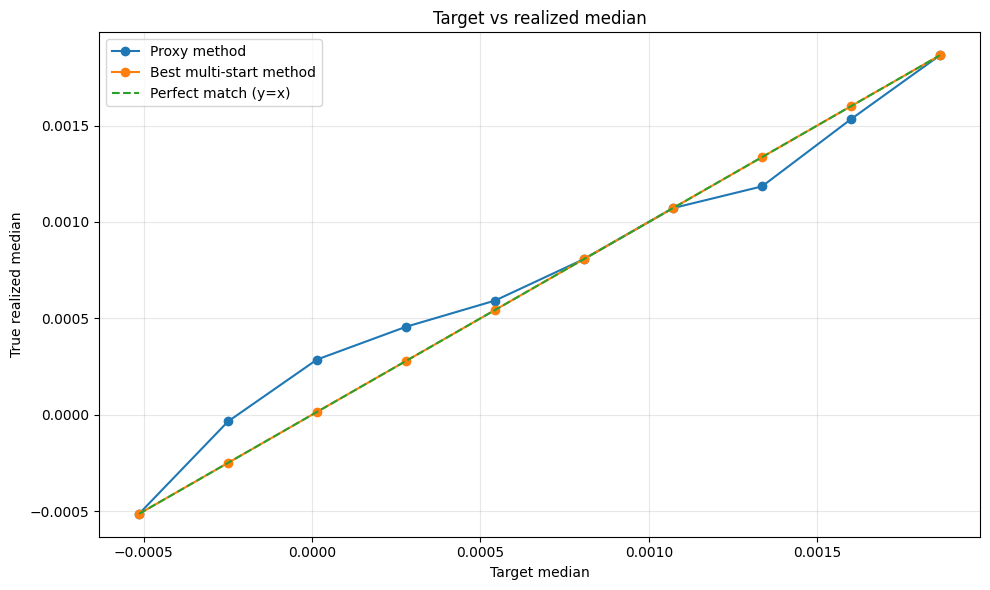

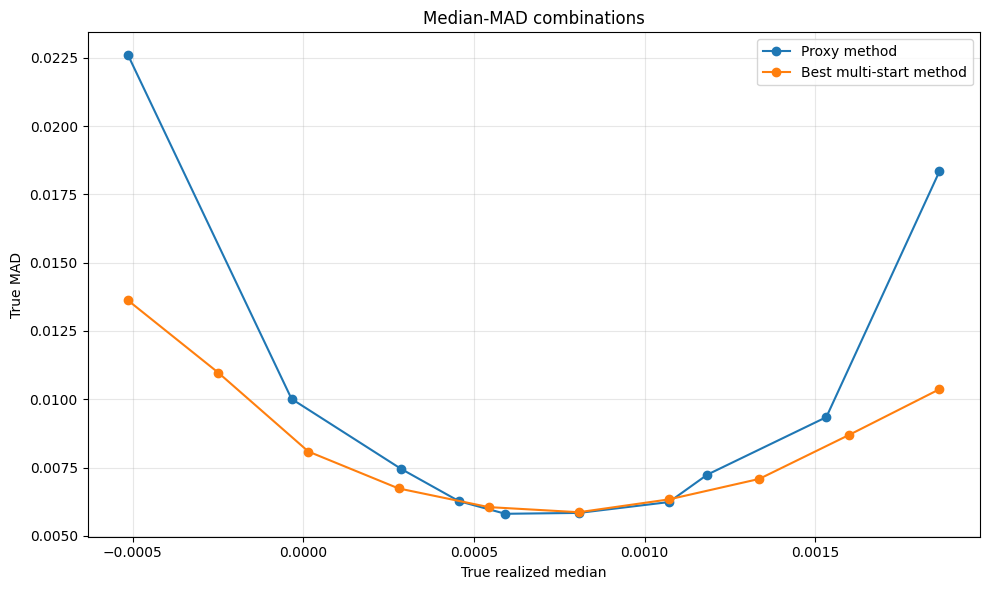

In [ ]:
# ============================================================
# 6) Plot the 10 median-MAD combinations
#    Proxy vs single-start vs multi-start
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_true_stats(R, weights):
    port_returns = R @ weights
    true_median = np.median(port_returns)
    true_mad = np.mean(np.abs(port_returns - true_median))
    return true_median, true_mad

R_train = returns_train.values
rows = []

n_portfolios = min(
    len(results_train_proxy),
    len(results_train_true)
)

for i in range(n_portfolios):
    proxy_res = results_train_proxy[i]
    multi_res = results_train_true[i]

    target = proxy_res["target_median"]

    proxy_med, proxy_mad = compute_true_stats(R_train, proxy_res["weights"])
    multi_med, multi_mad = compute_true_stats(R_train, multi_res["weights"])

    row = {
        "target_median": target,
        "proxy_true_median": proxy_med,
        "proxy_true_mad": proxy_mad,
        "multistart_true_median": multi_med,
        "multistart_true_mad": multi_mad,
    }

    if "results_train_single_start" in globals():
        single_res = results_train_single_start[i]
        single_med, single_mad = compute_true_stats(R_train, single_res["weights"])
        row["single_true_median"] = single_med
        row["single_true_mad"] = single_mad

    rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values("target_median").reset_index(drop=True)

# ------------------------------------------------------------
# Plot 1: target median vs realized median
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["target_median"],
    comparison_df["proxy_true_median"],
    marker="o",
    label="Proxy method"
)

if "single_true_median" in comparison_df.columns:
    plt.plot(
        comparison_df["target_median"],
        comparison_df["single_true_median"],
        marker="o",
        label="Single-start true method"
    )

plt.plot(
    comparison_df["target_median"],
    comparison_df["multistart_true_median"],
    marker="o",
    label="Best multi-start method"
)

xmin = comparison_df["target_median"].min()
xmax = comparison_df["target_median"].max()
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--", label="Perfect match (y=x)")

plt.xlabel("Target median")
plt.ylabel("True realized median")
plt.title("Target vs realized median")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: median-MAD frontier
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["proxy_true_median"],
    comparison_df["proxy_true_mad"],
    marker="o",
    label="Proxy method"
)

if "single_true_median" in comparison_df.columns:
    plt.plot(
        comparison_df["single_true_median"],
        comparison_df["single_true_mad"],
        marker="o",
        label="Single-start true method"
    )

plt.plot(
    comparison_df["multistart_true_median"],
    comparison_df["multistart_true_mad"],
    marker="o",
    label="Best multi-start method"
)

plt.xlabel("True realized median")
plt.ylabel("True MAD")
plt.title("Median-MAD combinations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Proxy portfolios evaluated on test sample:
   target_median    median       mad  target_mad  median_error  \
0      -0.000513  0.000867  0.005133    0.005280      0.001380   
1      -0.000249  0.000879  0.005063    0.005164      0.001129   
2       0.000015  0.000887  0.005018    0.005081      0.000872   
3       0.000279  0.001009  0.005063    0.005099      0.000730   
4       0.000543  0.000963  0.005056    0.005069      0.000420   
5       0.000808  0.000903  0.005054    0.005055      0.000095   
6       0.001072  0.001028  0.005065    0.005065     -0.000043   
7       0.001336  0.000906  0.005040    0.005053     -0.000430   
8       0.001600  0.000951  0.005053    0.005094     -0.000649   
9       0.001864  0.001004  0.005051    0.005122     -0.000860   

   abs_median_error  
0          0.001380  
1          0.001129  
2          0.000872  
3          0.000730  
4          0.000420  
5          0.000095  
6          0.000043  
7          0.000430  
8          0.000649  
9        

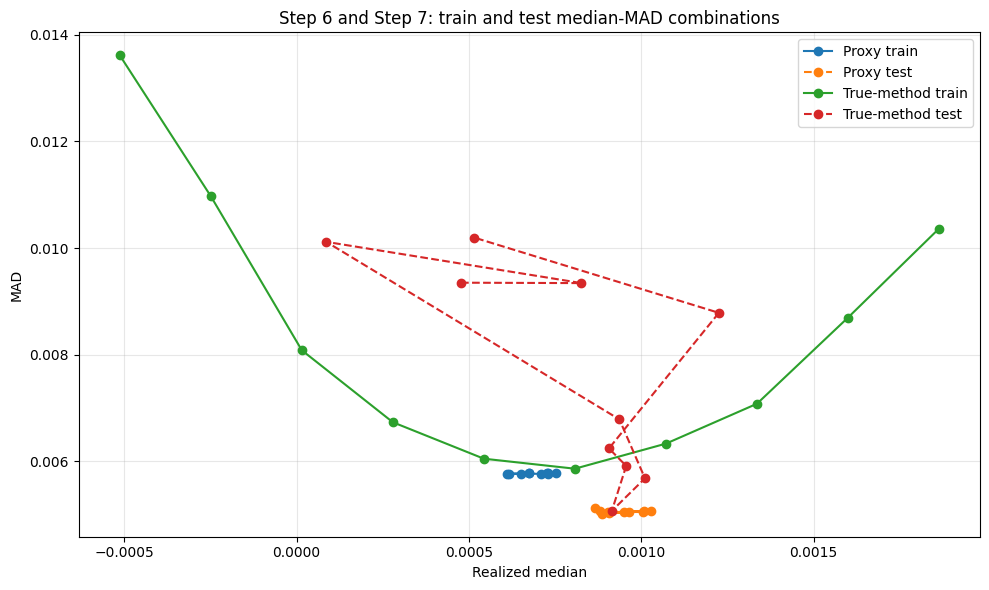

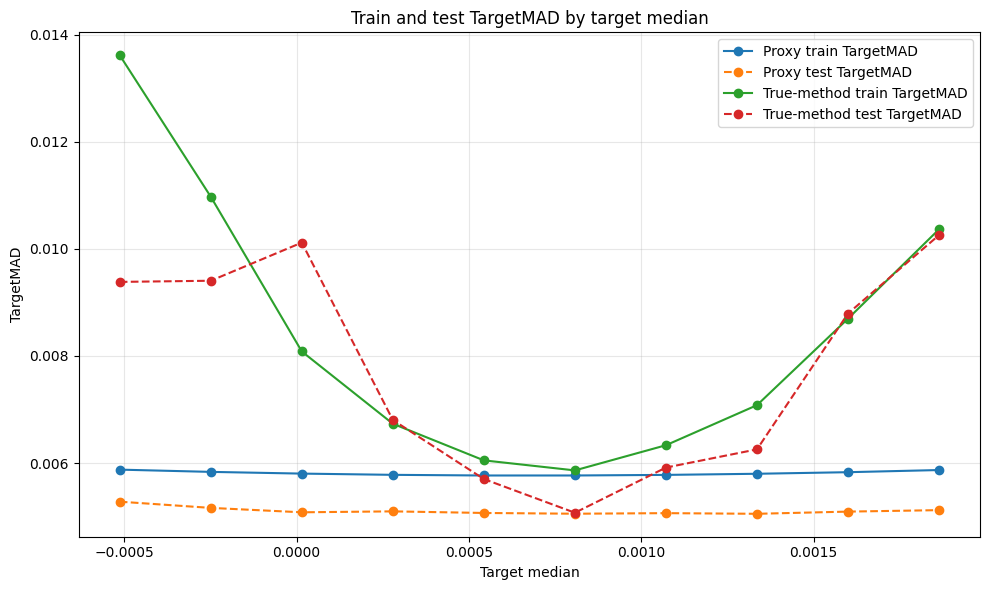


Saved:
  proxy_test_summary.csv
  true_method_test_summary.csv


In [ ]:
# ============================================================
# Step 7: Evaluate train portfolios on the test sample
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Test matrix
R_test = returns_test.values

def compute_out_of_sample_stats(R, weights, target_median):
    port_returns = R @ weights
    realized_median = np.median(port_returns)
    true_mad = np.mean(np.abs(port_returns - realized_median))
    target_mad = np.mean(np.abs(port_returns - target_median))
    median_error = realized_median - target_median

    return {
        "median": realized_median,
        "mad": true_mad,
        "target_mad": target_mad,
        "median_error": median_error,
        "abs_median_error": abs(median_error)
    }

# ------------------------------------------------------------
# Evaluate proxy and true-method portfolios on test sample
# ------------------------------------------------------------
proxy_test_results = []
true_test_results = []

n_portfolios = min(len(proxy_results), len(results_train_true))

for i in range(n_portfolios):
    proxy_res = proxy_results[i]
    true_res  = results_train_true[i]

    target = proxy_res["target_median"]

    proxy_eval = compute_out_of_sample_stats(
        R=R_test,
        weights=proxy_res["proxy_weights"],
        target_median=target
    )

    true_eval = compute_out_of_sample_stats(
        R=R_test,
        weights=true_res["weights"],
        target_median=target
    )

    proxy_test_results.append({
        "target_median": target,
        "median": proxy_eval["median"],
        "mad": proxy_eval["mad"],
        "target_mad": proxy_eval["target_mad"],
        "median_error": proxy_eval["median_error"],
        "abs_median_error": proxy_eval["abs_median_error"]
    })

    true_test_results.append({
        "target_median": target,
        "median": true_eval["median"],
        "mad": true_eval["mad"],
        "target_mad": true_eval["target_mad"],
        "median_error": true_eval["median_error"],
        "abs_median_error": true_eval["abs_median_error"]
    })

# ------------------------------------------------------------
# Convert to DataFrames
# ------------------------------------------------------------
proxy_test_df = pd.DataFrame(proxy_test_results).sort_values("target_median").reset_index(drop=True)
true_test_df  = pd.DataFrame(true_test_results).sort_values("target_median").reset_index(drop=True)

print("\nProxy portfolios evaluated on test sample:")
print(proxy_test_df)

print("\nTrue-method portfolios evaluated on test sample:")
print(true_test_df)

# ------------------------------------------------------------
# Also build train summary tables for plotting
# ------------------------------------------------------------
proxy_train_df = pd.DataFrame([
    {
        "target_median": r["target_median"],
        "median": r["proxy_true_median"],
        "mad": r["proxy_true_mad"],
        "target_mad": r["proxy_target_mad"],
        "median_error": r["proxy_median_error"],
        "abs_median_error": r["proxy_abs_median_error"]
    }
    for r in proxy_results
]).sort_values("target_median").reset_index(drop=True)

true_train_df = pd.DataFrame([
    {
        "target_median": r["target_median"],
        "median": r["median"],
        "mad": r["mad"],
        "target_mad": r["target_mad"],
        "median_error": r["median_error"],
        "abs_median_error": abs(r["median_error"])
    }
    for r in results_train_true
]).sort_values("target_median").reset_index(drop=True)

# ------------------------------------------------------------
# Plot 1: Step-6 / Step-7 style plot in the (median, MAD) plane
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    proxy_train_df["median"], proxy_train_df["mad"],
    marker="o", linestyle="-", label="Proxy train"
)

plt.plot(
    proxy_test_df["median"], proxy_test_df["mad"],
    marker="o", linestyle="--", label="Proxy test"
)

plt.plot(
    true_train_df["median"], true_train_df["mad"],
    marker="o", linestyle="-", label="True-method train"
)

plt.plot(
    true_test_df["median"], true_test_df["mad"],
    marker="o", linestyle="--", label="True-method test"
)

plt.xlabel("Realized median")
plt.ylabel("MAD")
plt.title("Step 6 and Step 7: train and test median-MAD combinations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Homogeneous comparison in the (median error, TargetMAD) logic
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    proxy_train_df["target_median"], proxy_train_df["target_mad"],
    marker="o", linestyle="-", label="Proxy train TargetMAD"
)

plt.plot(
    proxy_test_df["target_median"], proxy_test_df["target_mad"],
    marker="o", linestyle="--", label="Proxy test TargetMAD"
)

plt.plot(
    true_train_df["target_median"], true_train_df["target_mad"],
    marker="o", linestyle="-", label="True-method train TargetMAD"
)

plt.plot(
    true_test_df["target_median"], true_test_df["target_mad"],
    marker="o", linestyle="--", label="True-method test TargetMAD"
)

plt.xlabel("Target median")
plt.ylabel("TargetMAD")
plt.title("Train and test TargetMAD by target median")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
proxy_test_df.to_csv("proxy_test_summary.csv", index=False)
true_test_df.to_csv("true_method_test_summary.csv", index=False)

print("\nSaved:")
print("  proxy_test_summary.csv")
print("  true_method_test_summary.csv")